# input

In [1]:
import mne

fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"

raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_94570/2233789108.py:5: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname, preload=True)


Reading 0 ... 2542999  =      0.000 ...  2542.999 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



<Raw | main.fif, 324 x 2543000 (2543.0 s), ~6.14 GiB, data loaded>

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

In [3]:
sfreq = raw.info['sfreq']

# division eda

In [2]:
events = mne.find_events(raw)

Finding events on: STI101
805 events found on stim channel STI101
Event IDs: [8]


In [3]:
events

array([[  77770,       0,       8],
       [  82534,       0,       8],
       [  88149,       0,       8],
       ...,
       [2585804,       0,       8],
       [2589353,       0,       8],
       [2593068,       0,       8]], shape=(805, 3))

In [4]:
mag_picks = mne.pick_types(raw.info, meg='mag')
if len(mag_picks) > 0:
    channel_name = raw.ch_names[mag_picks[0]]
    print(f"Using channel: {channel_name}")
else:
    # Fallback to gradiometer if no magnetometers
    grad_picks = mne.pick_types(raw.info, meg='grad')
    channel_name = raw.ch_names[grad_picks[0]]
    print(f"Using channel: {channel_name}")

# Extract data from one channel as numpy array
data, times = raw[channel_name, :]
data = data.flatten()

# Create alpha-filtered version (8-13 Hz)
raw_alpha = raw.copy().filter(8, 13, picks=channel_name, verbose=False)
data_alpha, _ = raw_alpha[channel_name, :]
data_alpha = data_alpha.flatten()

Using channel: MEG0111


In [61]:
# Extract timestamps from CSV
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

In [7]:
for i in range(100):
    print(df_behav['fix_cross.started'][1] - df_behav['fix_cross.stopped'][1])

-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886
-0.4998639999998886


In [56]:
# Get MNE events (your STI101 events)
events = mne.find_events(raw, stim_channel='STI101', verbose=False)
event_times = events[:, 0] / raw.info['sfreq']  # Convert samples to seconds

In [57]:
print(f"Found {len(event_times)} MNE events")
print(f"Found {len(fix_cross_start)} fixation starts")
print(f"Found {len(fix_cross_stop)} fixation stops")

Found 805 MNE events
Found 808 fixation starts
Found 808 fixation stops


In [58]:
event_times[:5]

array([77.77 , 82.534, 88.149, 92.831, 97.963])

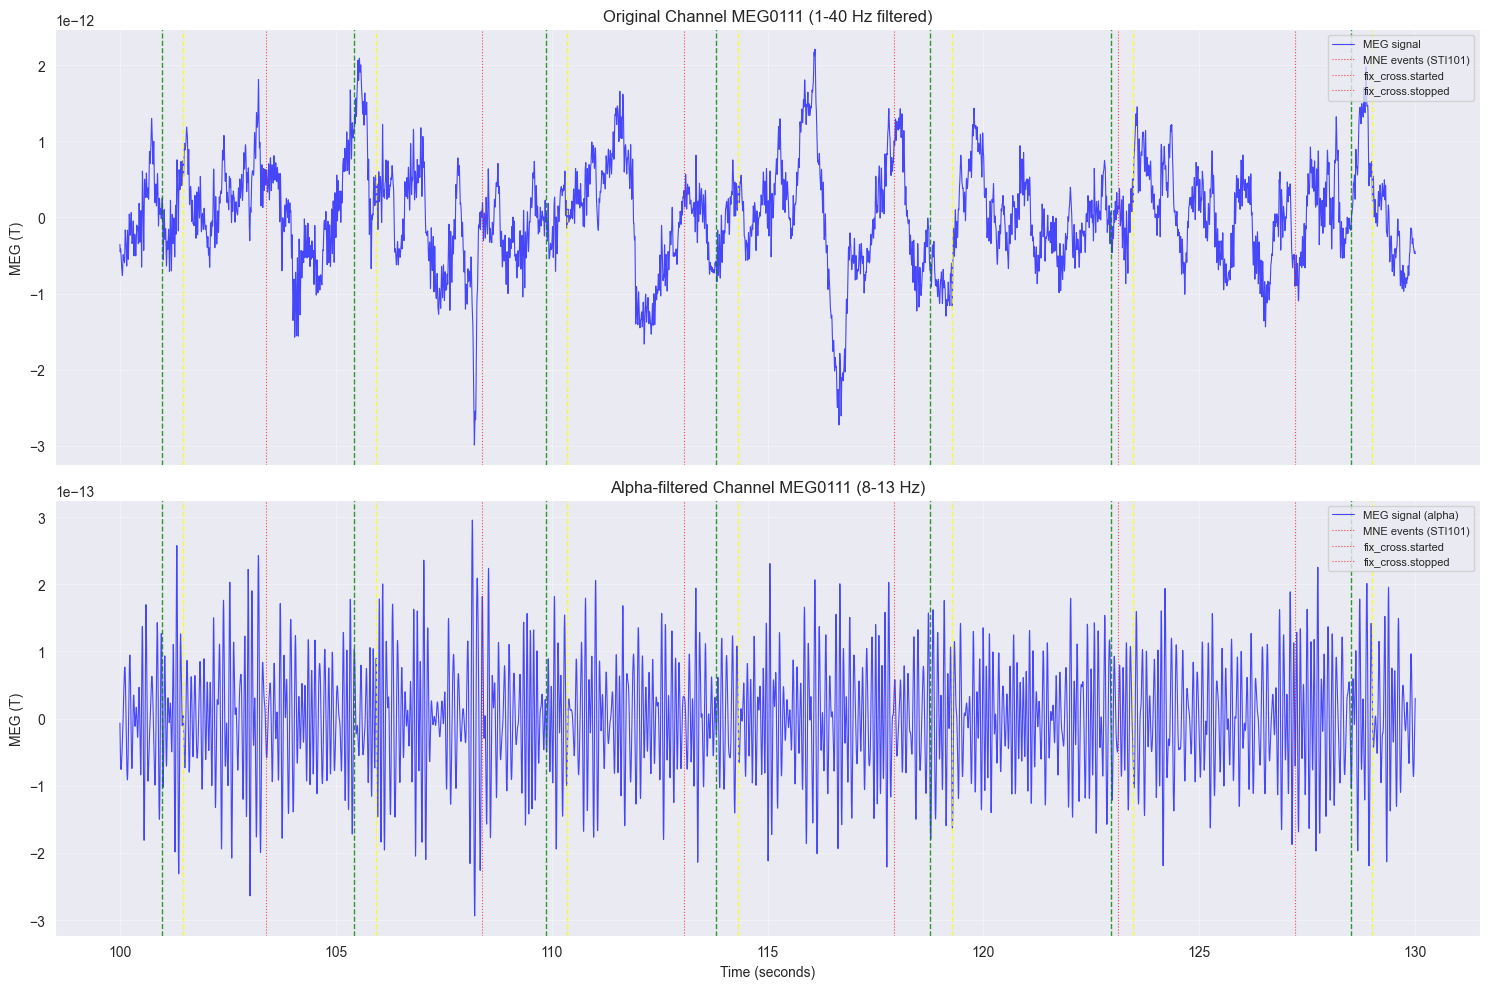

In [64]:
tmin, tmax = 100, 130
time_mask = (times >= tmin) & (times <= tmax)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ============================================================================
# TOP PLOT: Original channel with events
# ============================================================================
ax1.plot(times[time_mask], data[time_mask], 'b-', linewidth=0.8, alpha=0.7, label=channel_name)

# Add MNE events (red vertical lines)
for t in event_times:
    if tmin <= t <= tmax:
        ax1.axvline(x=t, color='red', linestyle=':', linewidth=0.8, alpha=0.7)

# Add fix_cross.started (green vertical lines)
for t in fix_cross_start:
    if tmin <= t <= tmax:
        ax1.axvline(x=t, color='green', linestyle='--', linewidth=1, alpha=0.8)

# Add fix_cross.stopped (blue vertical lines)
for t in fix_cross_stop:
    if tmin <= t <= tmax:
        ax1.axvline(x=t, color='yellow', linestyle='--', linewidth=1, alpha=0.8)

ax1.set_ylabel('MEG (T)', fontsize=10)
ax1.set_title(f'Original Channel {channel_name} (1-40 Hz filtered)', fontsize=12)
ax1.legend(['MEG signal', 'MNE events (STI101)', 'fix_cross.started', 'fix_cross.stopped'],
           loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# ============================================================================
# BOTTOM PLOT: Alpha-filtered channel with events
# ============================================================================
ax2.plot(times[time_mask], data_alpha[time_mask], 'b-', linewidth=0.8, alpha=0.7, label=f'{channel_name} (alpha)')

# Add same events
for t in event_times:
    if tmin <= t <= tmax:
        ax2.axvline(x=t, color='red', linestyle=':', linewidth=0.8, alpha=0.7)

for t in fix_cross_start:
    if tmin <= t <= tmax:
        ax2.axvline(x=t, color='green', linestyle='--', linewidth=1, alpha=0.8)

for t in fix_cross_stop:
    if tmin <= t <= tmax:
        ax2.axvline(x=t, color='yellow', linestyle='--', linewidth=1, alpha=0.8)

ax2.set_xlabel('Time (seconds)', fontsize=10)
ax2.set_ylabel('MEG (T)', fontsize=10)
ax2.set_title(f'Alpha-filtered Channel {channel_name} (8-13 Hz)', fontsize=12)
ax2.legend(['MEG signal (alpha)', 'MNE events (STI101)', 'fix_cross.started', 'fix_cross.stopped'],
           loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
check if stimulus is regular?

In [10]:
print("\n" + "="*60)
print("TIMING STATISTICS")
print("="*60)
print(f"First 5 MNE event times: {event_times[:5]}")
print(f"First 5 fix_cross.started: {fix_cross_start[:5]}")
print(f"First 5 fix_cross.stopped: {fix_cross_stop[:5]}")
print(f"Average fixation duration: {np.mean(fix_cross_stop - fix_cross_start):.3f} seconds")


TIMING STATISTICS
First 5 MNE event times: [77.77  82.534 88.149 92.831 97.963]
First 5 fix_cross.started: [22.8914514 27.639975  33.2716097 37.9534945 43.0852741]
First 5 fix_cross.stopped: [23.3913154 28.139825  33.7714346 38.4533753 43.5851028]
Average fixation duration: 0.500 seconds


# actual division

In [15]:
# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Extract segments
fixation_raw = []
fixation_alpha = []
non_fixation_raw = []
non_fixation_alpha = []

fixation_mask = np.zeros(len(times), dtype=bool)

for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)

    if start_idx < len(data) and stop_idx < len(data):
        fixation_raw.append(data[start_idx:stop_idx])
        fixation_alpha.append(data_alpha[start_idx:stop_idx])
        fixation_mask[start_idx:stop_idx] = True

# Non-fixation segments (split into chunks)
non_fix_idx = np.where(~fixation_mask)[0]
seg_len = int(np.mean([len(s) for s in fixation_raw]))

for i in range(0, len(non_fix_idx), seg_len):
    end = min(i + seg_len, len(non_fix_idx))
    if end - i > 10:
        non_fixation_raw.append(data[non_fix_idx[i:end]])
        non_fixation_alpha.append(data_alpha[non_fix_idx[i:end]])

print(f"Fixation segments: {len(fixation_raw)}")
print(f"Non-fixation segments: {len(non_fixation_raw)}")

Fixation segments: 808
Non-fixation segments: 4287


## plots

### dist

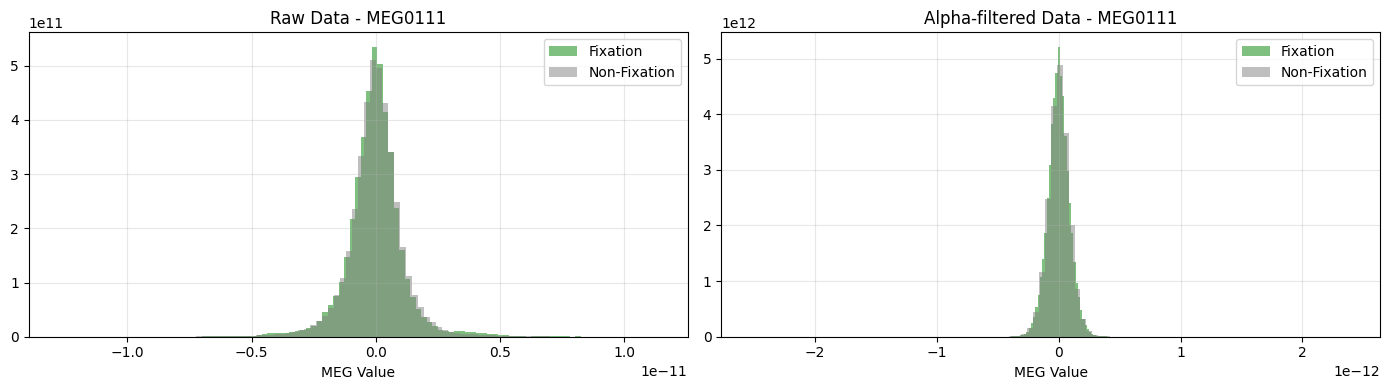

Raw - Fixation mean: -2.087e-14, Non-fixation: 5.109e-15
Alpha - Fixation mean: 2.714e-16, Non-fixation: -3.054e-17


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw data
fix_vals = np.concatenate(fixation_raw)
nonfix_vals = np.concatenate(non_fixation_raw)

axes[0].hist(fix_vals, bins=100, alpha=0.5, label='Fixation', density=True, color='green')
axes[0].hist(nonfix_vals, bins=100, alpha=0.5, label='Non-Fixation', density=True, color='gray')
axes[0].set_xlabel('MEG Value')
axes[0].set_title(f'Raw Data - {channel_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alpha data
fix_vals_a = np.concatenate(fixation_alpha)
nonfix_vals_a = np.concatenate(non_fixation_alpha)

axes[1].hist(fix_vals_a, bins=100, alpha=0.5, label='Fixation', density=True, color='green')
axes[1].hist(nonfix_vals_a, bins=100, alpha=0.5, label='Non-Fixation', density=True, color='gray')
axes[1].set_xlabel('MEG Value')
axes[1].set_title(f'Alpha-filtered Data - {channel_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"Raw - Fixation mean: {np.mean(fix_vals):.3e}, Non-fixation: {np.mean(nonfix_vals):.3e}")
print(f"Alpha - Fixation mean: {np.mean(fix_vals_a):.3e}, Non-fixation: {np.mean(nonfix_vals_a):.3e}")

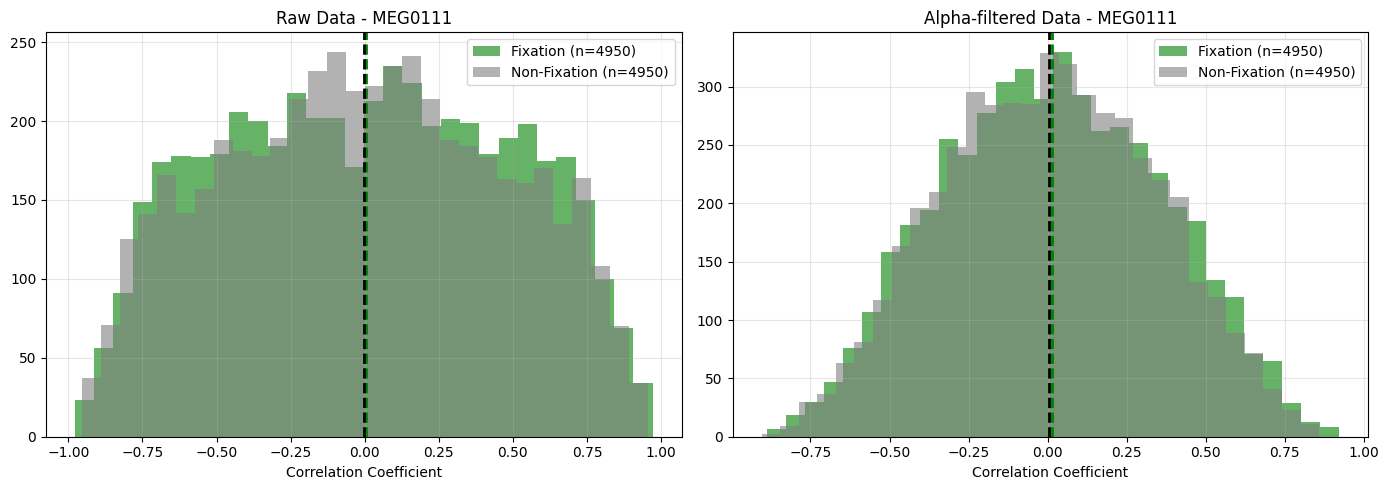

Raw correlation mean - Fixation: 0.006, Non-fixation: -0.002
Alpha correlation mean - Fixation: 0.014, Non-fixation: 0.006


In [19]:
from scipy import stats

def get_correlations(segments):
    """Calculate pairwise correlations between segments"""
    corrs = []
    n = min(len(segments), 100)  # Limit to 100 segments
    for i in range(n):
        for j in range(i+1, n):
            min_len = min(len(segments[i]), len(segments[j]))
            if min_len > 5:
                corr, _ = stats.pearsonr(segments[i][:min_len], segments[j][:min_len])
                corrs.append(corr)
    return np.array(corrs)

# Calculate correlations
raw_fix_corr = get_correlations(fixation_raw)
raw_nonfix_corr = get_correlations(non_fixation_raw)
alpha_fix_corr = get_correlations(fixation_alpha)
alpha_nonfix_corr = get_correlations(non_fixation_alpha)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw data
axes[0].hist(raw_fix_corr, bins=30, alpha=0.6, label=f'Fixation (n={len(raw_fix_corr)})', color='green')
axes[0].hist(raw_nonfix_corr, bins=30, alpha=0.6, label=f'Non-Fixation (n={len(raw_nonfix_corr)})', color='gray')
axes[0].axvline(np.mean(raw_fix_corr), color='green', linestyle='--', linewidth=2)
axes[0].axvline(np.mean(raw_nonfix_corr), color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title(f'Raw Data - {channel_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alpha data
axes[1].hist(alpha_fix_corr, bins=30, alpha=0.6, label=f'Fixation (n={len(alpha_fix_corr)})', color='green')
axes[1].hist(alpha_nonfix_corr, bins=30, alpha=0.6, label=f'Non-Fixation (n={len(alpha_nonfix_corr)})', color='gray')
axes[1].axvline(np.mean(alpha_fix_corr), color='green', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(alpha_nonfix_corr), color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title(f'Alpha-filtered Data - {channel_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Raw correlation mean - Fixation: {np.mean(raw_fix_corr):.3f}, Non-fixation: {np.mean(raw_nonfix_corr):.3f}")
print(f"Alpha correlation mean - Fixation: {np.mean(alpha_fix_corr):.3f}, Non-fixation: {np.mean(alpha_nonfix_corr):.3f}")

Calculating coherence (may take a minute)...


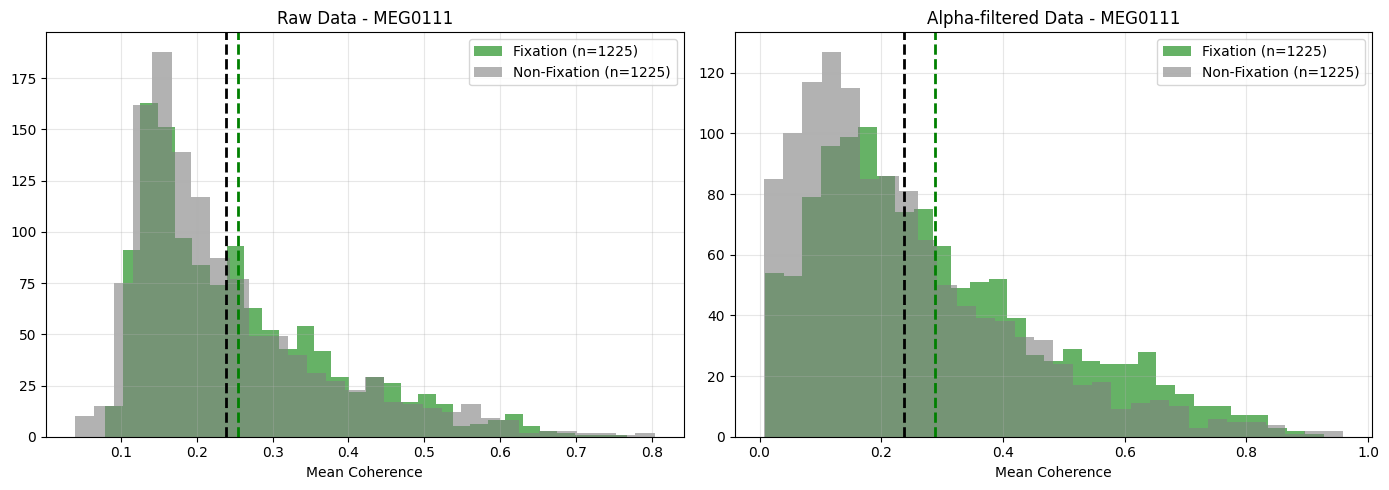

Raw coherence mean - Fixation: 0.2548, Non-fixation: 0.2388
Alpha coherence mean - Fixation: 0.2877, Non-fixation: 0.2378


In [20]:
from scipy.signal import coherence

def get_coherence(segments, sfreq):
    """Calculate pairwise coherence between segments"""
    coh_vals = []
    n = min(len(segments), 50)  # Limit to 50 segments for speed
    for i in range(n):
        for j in range(i+1, n):
            min_len = min(len(segments[i]), len(segments[j]))
            if min_len > 128:
                f, Cxy = coherence(segments[i][:min_len], segments[j][:min_len],
                                   fs=sfreq, nperseg=min(128, min_len//2))
                coh_vals.append(np.mean(Cxy))
    return np.array(coh_vals)

# Calculate coherence
print("Calculating coherence (may take a minute)...")
raw_fix_coh = get_coherence(fixation_raw, sfreq)
raw_nonfix_coh = get_coherence(non_fixation_raw, sfreq)
alpha_fix_coh = get_coherence(fixation_alpha, sfreq)
alpha_nonfix_coh = get_coherence(non_fixation_alpha, sfreq)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw data
axes[0].hist(raw_fix_coh, bins=30, alpha=0.6, label=f'Fixation (n={len(raw_fix_coh)})', color='green')
axes[0].hist(raw_nonfix_coh, bins=30, alpha=0.6, label=f'Non-Fixation (n={len(raw_nonfix_coh)})', color='gray')
axes[0].axvline(np.mean(raw_fix_coh), color='green', linestyle='--', linewidth=2)
axes[0].axvline(np.mean(raw_nonfix_coh), color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel('Mean Coherence')
axes[0].set_title(f'Raw Data - {channel_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alpha data
axes[1].hist(alpha_fix_coh, bins=30, alpha=0.6, label=f'Fixation (n={len(alpha_fix_coh)})', color='green')
axes[1].hist(alpha_nonfix_coh, bins=30, alpha=0.6, label=f'Non-Fixation (n={len(alpha_nonfix_coh)})', color='gray')
axes[1].axvline(np.mean(alpha_fix_coh), color='green', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(alpha_nonfix_coh), color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Mean Coherence')
axes[1].set_title(f'Alpha-filtered Data - {channel_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Raw coherence mean - Fixation: {np.mean(raw_fix_coh):.4f}, Non-fixation: {np.mean(raw_nonfix_coh):.4f}")
print(f"Alpha coherence mean - Fixation: {np.mean(alpha_fix_coh):.4f}, Non-fixation: {np.mean(alpha_nonfix_coh):.4f}")

### 100 plots (dist but visible)

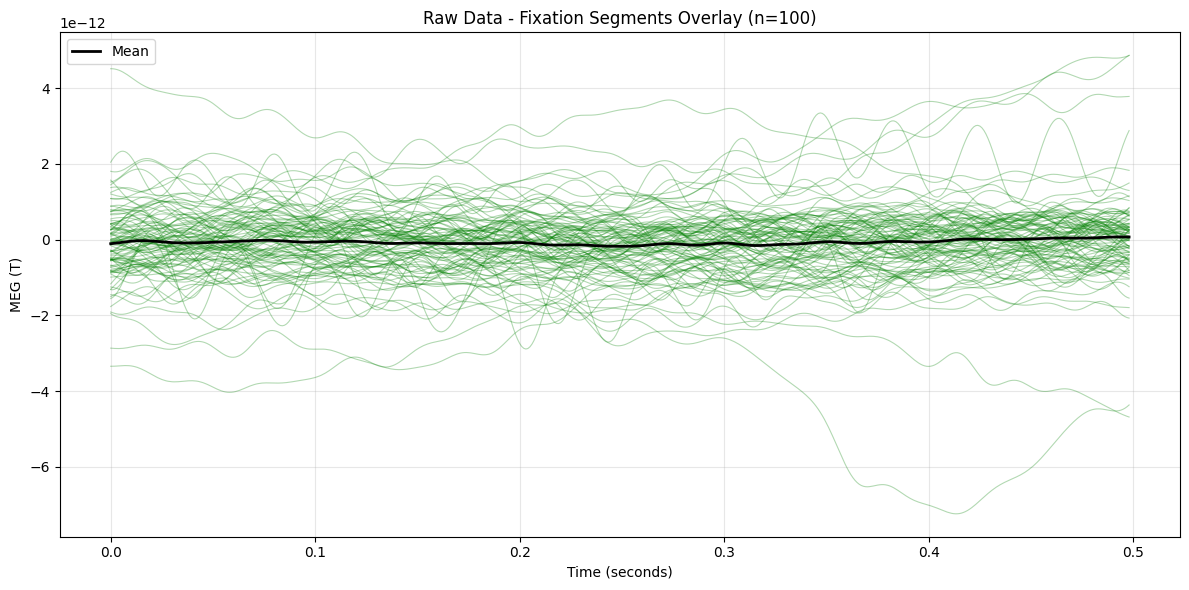

Segment length: 0.499 seconds


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Select 20 fixation segments
n_segments = 20
fix_idx = np.random.choice(len(fixation_raw), 100, replace=False)

# Find min length to align all segments
min_len = min([len(fixation_raw[i]) for i in fix_idx])
time_axis = np.arange(min_len) / sfreq

# Trim all segments to same length
trimmed_segments = [fixation_raw[i][:min_len] for i in fix_idx]

# Plot
plt.figure(figsize=(12, 6))

for seg in trimmed_segments:
    plt.plot(time_axis, seg, 'g-', alpha=0.3, linewidth=0.8)

# Add mean line
mean_seg = np.mean(trimmed_segments, axis=0)
plt.plot(time_axis, mean_seg, 'k-', linewidth=2, label='Mean')

plt.xlabel('Time (seconds)')
plt.ylabel('MEG (T)')
plt.title(f'Raw Data - Fixation Segments Overlay (n={len(trimmed_segments)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Segment length: {min_len/sfreq:.3f} seconds")

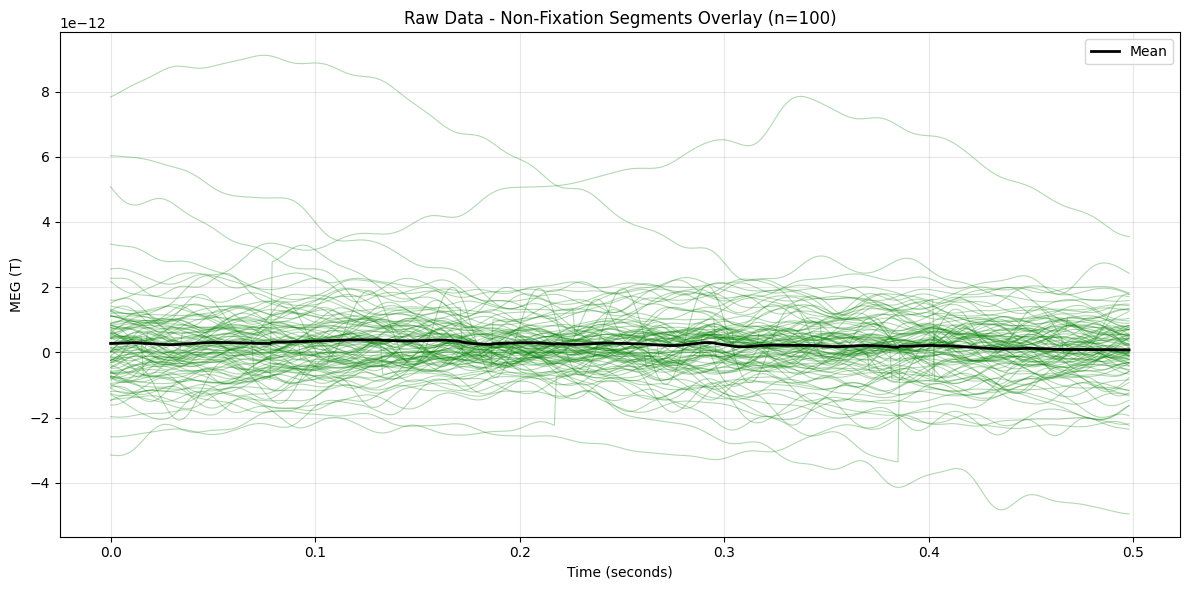

Segment length: 0.499 seconds


In [32]:
# Select 20 non-fixation segments
nonfix_idx = np.random.choice(len(non_fixation_raw), 100, replace=False)

# Find min length
min_len = min([len(non_fixation_raw[i]) for i in nonfix_idx])
time_axis = np.arange(min_len) / sfreq

# Trim to same length
trimmed_segments = [non_fixation_raw[i][:min_len] for i in nonfix_idx]

# Plot
plt.figure(figsize=(12, 6))

for seg in trimmed_segments:
    plt.plot(time_axis, seg, 'g-', alpha=0.3, linewidth=0.8)

# Add mean line
mean_seg = np.mean(trimmed_segments, axis=0)
plt.plot(time_axis, mean_seg, 'k-', linewidth=2, label='Mean')

plt.xlabel('Time (seconds)')
plt.ylabel('MEG (T)')
plt.title(f'Raw Data - Non-Fixation Segments Overlay (n={len(trimmed_segments)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Segment length: {min_len/sfreq:.3f} seconds")

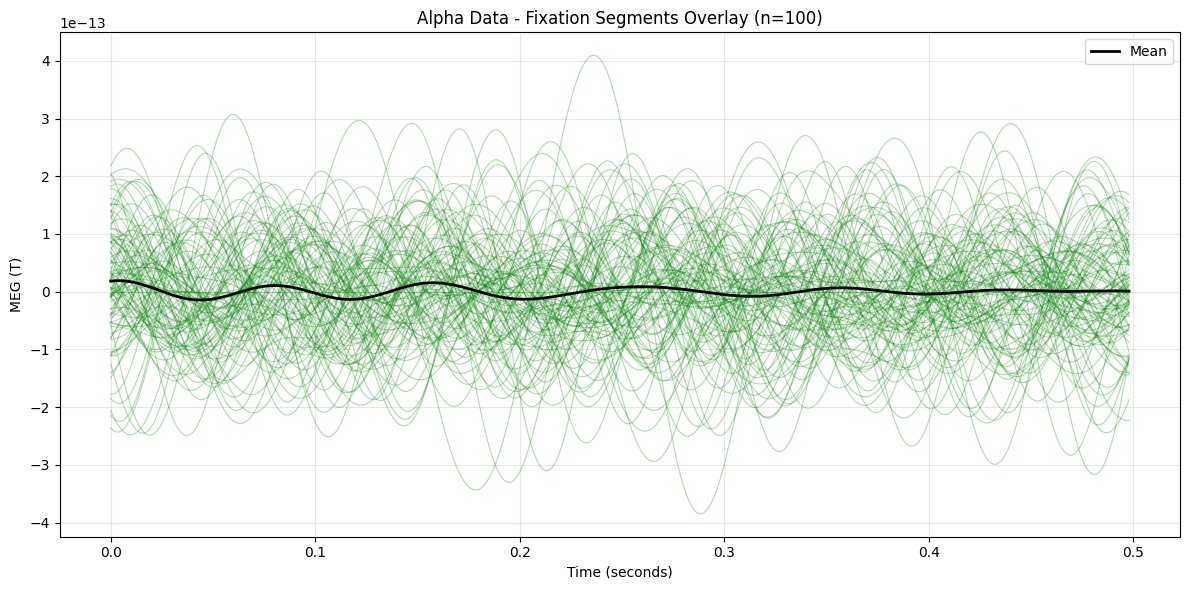

Segment length: 0.499 seconds


In [30]:
# Select 20 fixation segments (alpha)
fix_idx = np.random.choice(len(fixation_alpha), 100, replace=False)

# Find min length
min_len = min([len(fixation_alpha[i]) for i in fix_idx])
time_axis = np.arange(min_len) / sfreq

# Trim to same length
trimmed_segments = [fixation_alpha[i][:min_len] for i in fix_idx]

# Plot
plt.figure(figsize=(12, 6))

for seg in trimmed_segments:
    plt.plot(time_axis, seg, 'g-', alpha=0.3, linewidth=0.8)

# Add mean line
mean_seg = np.mean(trimmed_segments, axis=0)
plt.plot(time_axis, mean_seg, 'k-', linewidth=2, label='Mean')

plt.xlabel('Time (seconds)')
plt.ylabel('MEG (T)')
plt.title(f'Alpha Data - Fixation Segments Overlay (n={len(trimmed_segments)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Segment length: {min_len/sfreq:.3f} seconds")

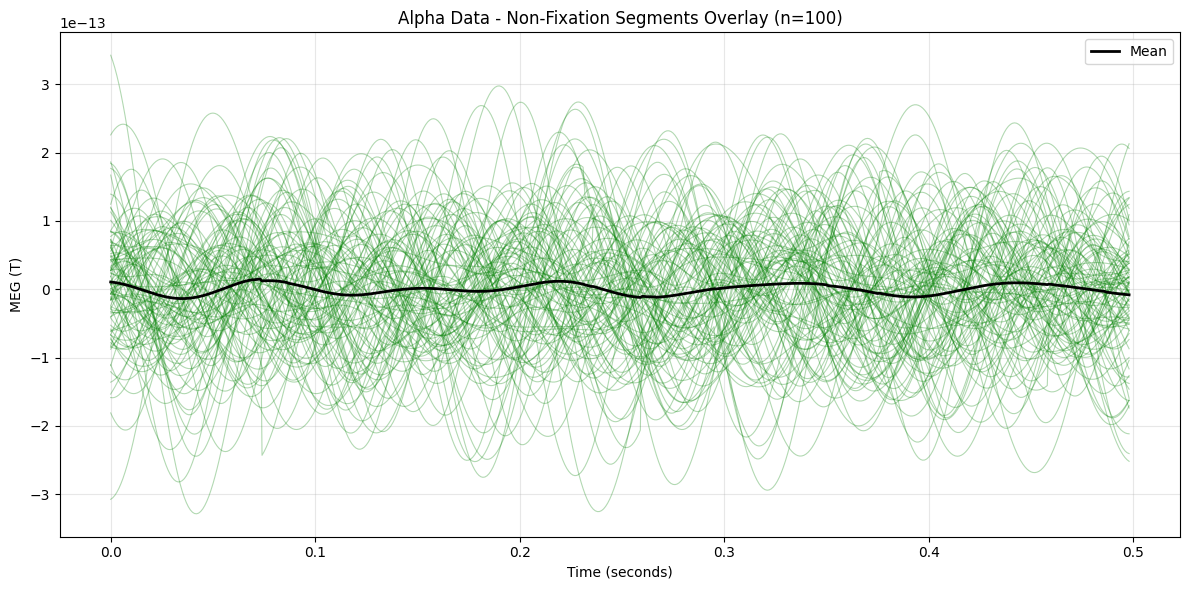

Segment length: 0.499 seconds


In [29]:
# Select 20 non-fixation segments (alpha)
nonfix_idx = np.random.choice(len(non_fixation_alpha), 100, replace=False)

# Find min length
min_len = min([len(non_fixation_alpha[i]) for i in nonfix_idx])
time_axis = np.arange(min_len) / sfreq

# Trim to same length
trimmed_segments = [non_fixation_alpha[i][:min_len] for i in nonfix_idx]

# Plot
plt.figure(figsize=(12, 6))

for seg in trimmed_segments:
    plt.plot(time_axis, seg, 'g-', alpha=0.3, linewidth=0.8)

# Add mean line
mean_seg = np.mean(trimmed_segments, axis=0)
plt.plot(time_axis, mean_seg, 'k-', linewidth=2, label='Mean')

plt.xlabel('Time (seconds)')
plt.ylabel('MEG (T)')
plt.title(f'Alpha Data - Non-Fixation Segments Overlay (n={len(trimmed_segments)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Segment length: {min_len/sfreq:.3f} seconds")

### better 100 plots

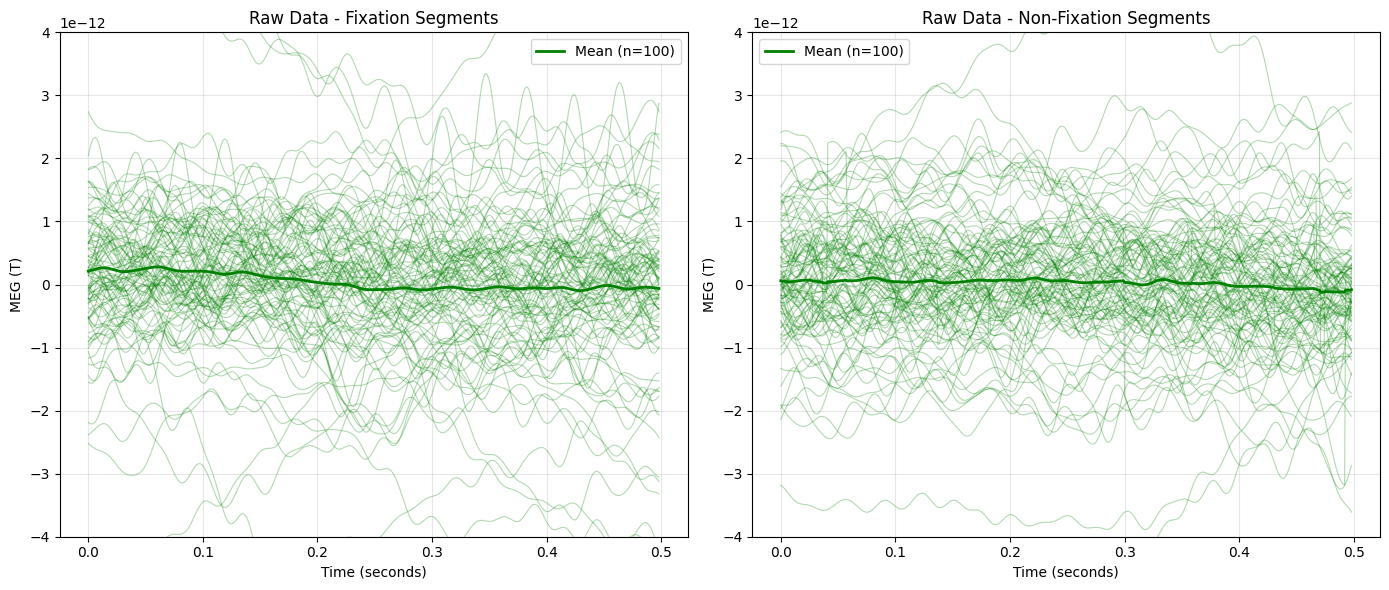

In [43]:
# Raw fixation
fix_idx_raw = np.random.choice(len(fixation_raw), min(n_segments, len(fixation_raw)), replace=False)
min_len_fix_raw = min([len(fixation_raw[i]) for i in fix_idx_raw])
time_axis_fix_raw = np.arange(min_len_fix_raw) / sfreq
trimmed_fix_raw = [fixation_raw[i][:min_len_fix_raw] for i in fix_idx_raw]

# Raw non-fixation
nonfix_idx_raw = np.random.choice(len(non_fixation_raw), min(n_segments, len(non_fixation_raw)), replace=False)
min_len_nonfix_raw = min([len(non_fixation_raw[i]) for i in nonfix_idx_raw])
time_axis_nonfix_raw = np.arange(min_len_nonfix_raw) / sfreq
trimmed_nonfix_raw = [non_fixation_raw[i][:min_len_nonfix_raw] for i in nonfix_idx_raw]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left subplot: Fixation
for seg in trimmed_fix_raw:
    axes[0].plot(time_axis_fix_raw, seg, 'g-', alpha=0.3, linewidth=0.8)
mean_fix = np.mean(trimmed_fix_raw, axis=0)
axes[0].plot(time_axis_fix_raw, mean_fix, 'g-', linewidth=2, label=f'Mean (n={len(trimmed_fix_raw)})')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Raw Data - Fixation Segments')
axes[0].set_ylim(-4e-12, 4e-12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right subplot: Non-Fixation
for seg in trimmed_nonfix_raw:
    axes[1].plot(time_axis_nonfix_raw, seg, 'g-', alpha=0.3, linewidth=0.8)
mean_nonfix = np.mean(trimmed_nonfix_raw, axis=0)
axes[1].plot(time_axis_nonfix_raw, mean_nonfix, 'g-', linewidth=2, label=f'Mean (n={len(trimmed_nonfix_raw)})')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Raw Data - Non-Fixation Segments')
axes[1].set_ylim(-4e-12, 4e-12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

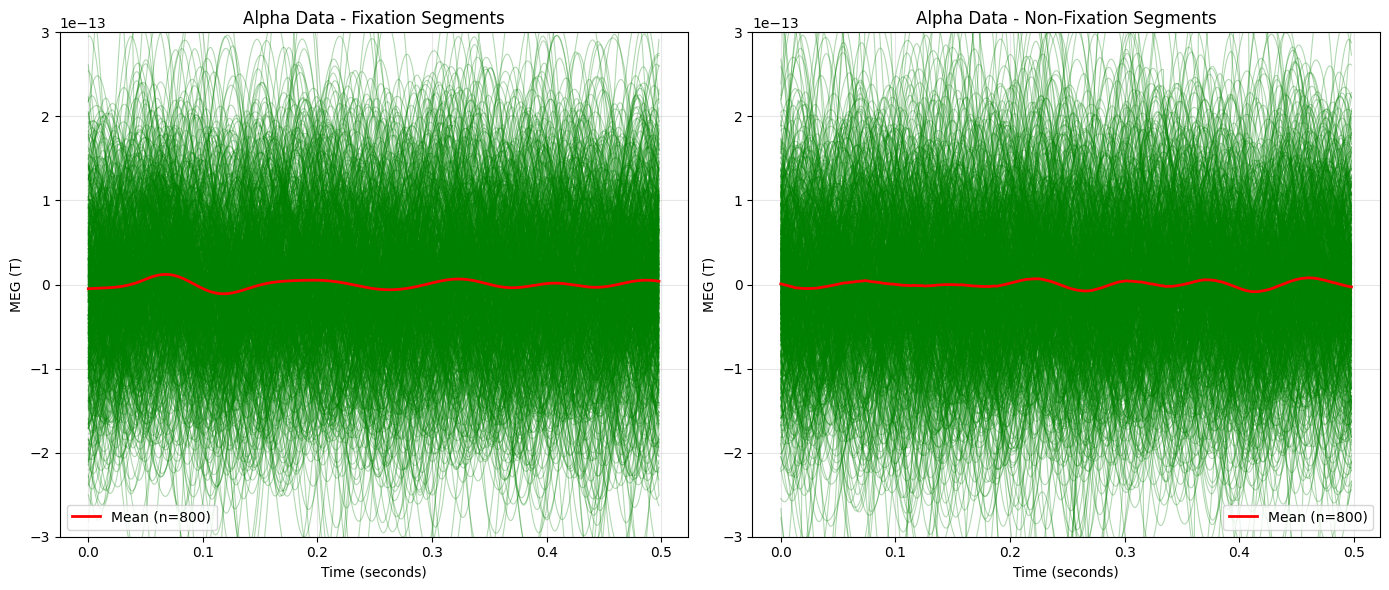

In [54]:
n_segments = 800

fix_idx_alpha = np.random.choice(len(fixation_alpha), min(n_segments, len(fixation_alpha)), replace=False)
min_len_fix_alpha = min([len(fixation_alpha[i]) for i in fix_idx_alpha])
time_axis_fix_alpha = np.arange(min_len_fix_alpha) / sfreq
trimmed_fix_alpha = [fixation_alpha[i][:min_len_fix_alpha] for i in fix_idx_alpha]

# Alpha non-fixation
nonfix_idx_alpha = np.random.choice(len(non_fixation_alpha), min(n_segments, len(non_fixation_alpha)), replace=False)
min_len_nonfix_alpha = min([len(non_fixation_alpha[i]) for i in nonfix_idx_alpha])
time_axis_nonfix_alpha = np.arange(min_len_nonfix_alpha) / sfreq
trimmed_nonfix_alpha = [non_fixation_alpha[i][:min_len_nonfix_alpha] for i in nonfix_idx_alpha]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left subplot: Fixation
for seg in trimmed_fix_alpha:
    axes[0].plot(time_axis_fix_alpha, seg, 'g-', alpha=0.3, linewidth=0.8)
mean_fix = np.mean(trimmed_fix_alpha, axis=0)
axes[0].plot(time_axis_fix_alpha, mean_fix, 'r-', linewidth=2, label=f'Mean (n={len(trimmed_fix_alpha)})')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Alpha Data - Fixation Segments')
axes[0].set_ylim(-0.3e-12, 0.3e-12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right subplot: Non-Fixation
for seg in trimmed_nonfix_alpha:
    axes[1].plot(time_axis_nonfix_alpha, seg, 'g-', alpha=0.3, linewidth=0.8)
mean_nonfix = np.mean(trimmed_nonfix_alpha, axis=0)
axes[1].plot(time_axis_nonfix_alpha, mean_nonfix, 'r-', linewidth=2, label=f'Mean (n={len(trimmed_nonfix_alpha)})')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Alpha Data - Non-Fixation Segments')
axes[1].set_ylim(-0.3e-12, 0.3e-12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## other bands

In [56]:
raw_delta = raw.copy().filter(1, 4, picks=channel_name, verbose=False)
data_delta, _ = raw_delta[channel_name, :]
data_delta = data_delta.flatten()

In [59]:
raw_theta = raw.copy().filter(4, 8, picks=channel_name, verbose=False)
data_theta, _ = raw_theta[channel_name, :]
data_theta = data_theta.flatten()

In [60]:
raw_beta = raw.copy().filter(13, 30, picks=channel_name, verbose=False)
data_beta, _ = raw_beta[channel_name, :]
data_beta = data_beta.flatten()

In [61]:
raw_gamma = raw.copy().filter(30, 40, picks=channel_name, verbose=False)
data_gamma, _ = raw_gamma[channel_name, :]
data_gamma = data_gamma.flatten()

In [73]:
n_segments = 100

### delta

In [74]:
fixation_delta = []
non_fixation_delta = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    if start_idx < len(data_delta) and stop_idx < len(data_delta):
        fixation_delta.append(data_delta[start_idx:stop_idx])

non_fix_idx = np.where(~fixation_mask)[0]
seg_len = int(np.mean([len(s) for s in fixation_delta]))
for i in range(0, len(non_fix_idx), seg_len):
    end = min(i + seg_len, len(non_fix_idx))
    if end - i > 10:
        non_fixation_delta.append(data_delta[non_fix_idx[i:end]])

fix_idx = np.random.choice(len(fixation_delta), min(n_segments, len(fixation_delta)), replace=False)
nonfix_idx = np.random.choice(len(non_fixation_delta), min(n_segments, len(non_fixation_delta)), replace=False)

# Fixation
min_len_fix = min([len(fixation_delta[i]) for i in fix_idx])
time_axis_fix = np.arange(min_len_fix) / sfreq
trimmed_fix = [fixation_delta[i][:min_len_fix] for i in fix_idx]

# Non-fixation
min_len_nonfix = min([len(non_fixation_delta[i]) for i in nonfix_idx])
time_axis_nonfix = np.arange(min_len_nonfix) / sfreq
trimmed_nonfix = [non_fixation_delta[i][:min_len_nonfix] for i in nonfix_idx]

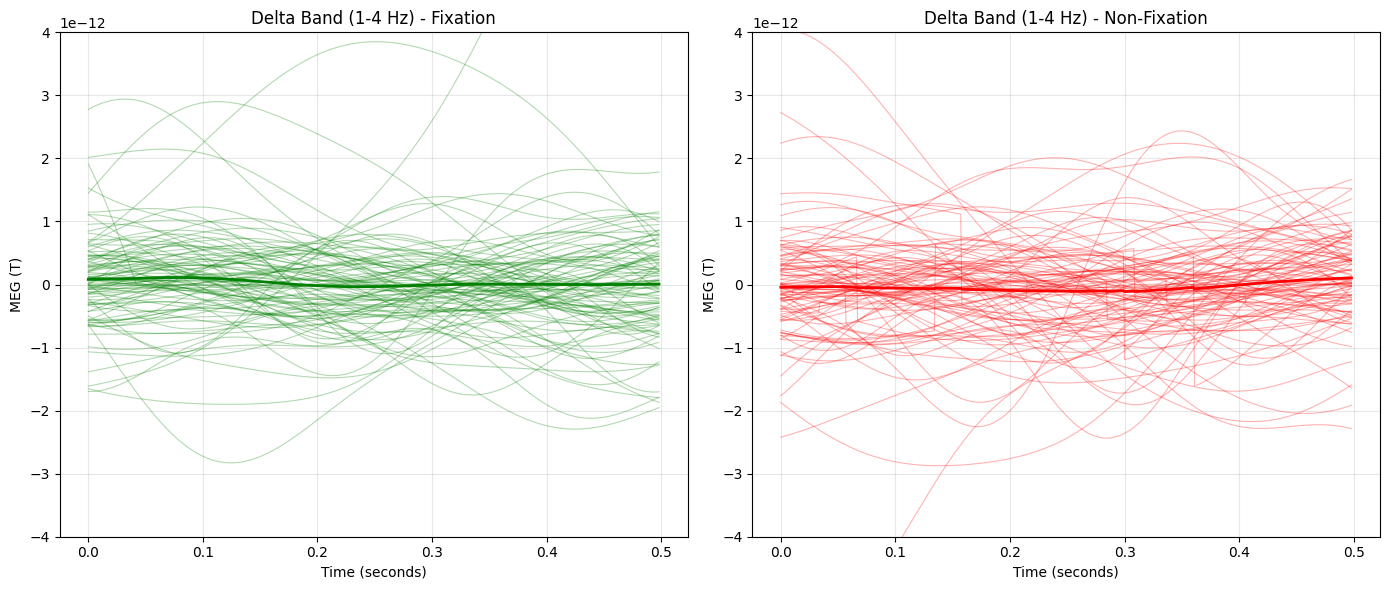

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixation
for seg in trimmed_fix:
    axes[0].plot(time_axis_fix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[0].plot(time_axis_fix, np.mean(trimmed_fix, axis=0), 'g-', linewidth=2)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Delta Band (1-4 Hz) - Fixation')
axes[0].set_ylim(-4e-12, 4e-12)
axes[0].grid(True, alpha=0.3)

# Non-fixation
for seg in trimmed_nonfix:
    axes[1].plot(time_axis_nonfix, seg, 'r-', alpha=0.3, linewidth=0.8)
axes[1].plot(time_axis_nonfix, np.mean(trimmed_nonfix, axis=0), 'r-', linewidth=2)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Delta Band (1-4 Hz) - Non-Fixation')
axes[1].set_ylim(-4e-12, 4e-12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### beta

In [76]:
fixation_beta = []
non_fixation_beta = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    if start_idx < len(data_beta) and stop_idx < len(data_beta):
        fixation_beta.append(data_beta[start_idx:stop_idx])

for i in range(0, len(non_fix_idx), seg_len):
    end = min(i + seg_len, len(non_fix_idx))
    if end - i > 10:
        non_fixation_beta.append(data_beta[non_fix_idx[i:end]])

# Select 20 segments
fix_idx = np.random.choice(len(fixation_beta), min(n_segments, len(fixation_beta)), replace=False)
nonfix_idx = np.random.choice(len(non_fixation_beta), min(n_segments, len(non_fixation_beta)), replace=False)

# Fixation
min_len_fix = min([len(fixation_beta[i]) for i in fix_idx])
time_axis_fix = np.arange(min_len_fix) / sfreq
trimmed_fix = [fixation_beta[i][:min_len_fix] for i in fix_idx]

# Non-fixation
min_len_nonfix = min([len(non_fixation_beta[i]) for i in nonfix_idx])
time_axis_nonfix = np.arange(min_len_nonfix) / sfreq
trimmed_nonfix = [non_fixation_beta[i][:min_len_nonfix] for i in nonfix_idx]

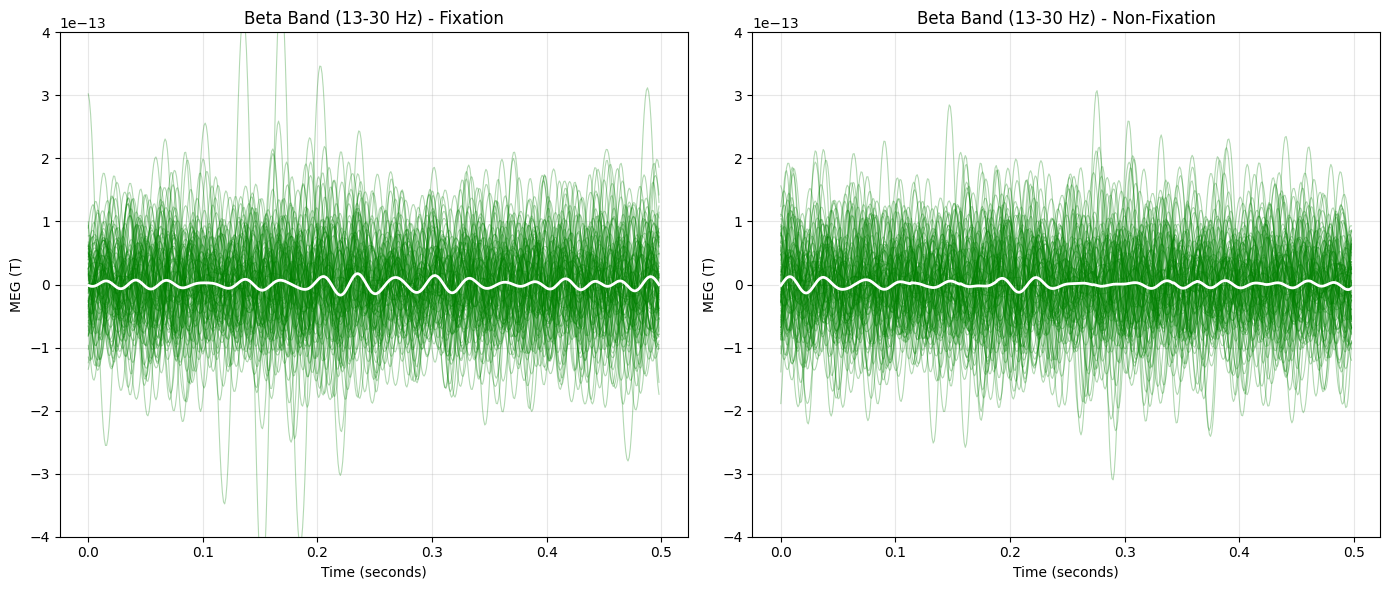

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixation
for seg in trimmed_fix:
    axes[0].plot(time_axis_fix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[0].plot(time_axis_fix, np.mean(trimmed_fix, axis=0), 'white', linewidth=2)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Beta Band (13-30 Hz) - Fixation')
axes[0].set_ylim(-4e-13, 4e-13)
axes[0].grid(True, alpha=0.3)

# Non-fixation
for seg in trimmed_nonfix:
    axes[1].plot(time_axis_nonfix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[1].plot(time_axis_nonfix, np.mean(trimmed_nonfix, axis=0), 'white', linewidth=2)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Beta Band (13-30 Hz) - Non-Fixation')
axes[1].set_ylim(-4e-13, 4e-13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### theta

In [78]:
fixation_theta = []
non_fixation_theta = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    if start_idx < len(data_theta) and stop_idx < len(data_theta):
        fixation_theta.append(data_theta[start_idx:stop_idx])

for i in range(0, len(non_fix_idx), seg_len):
    end = min(i + seg_len, len(non_fix_idx))
    if end - i > 10:
        non_fixation_theta.append(data_theta[non_fix_idx[i:end]])

# Select 20 segments
fix_idx = np.random.choice(len(fixation_theta), min(n_segments, len(fixation_theta)), replace=False)
nonfix_idx = np.random.choice(len(non_fixation_theta), min(n_segments, len(non_fixation_theta)), replace=False)

# Fixation
min_len_fix = min([len(fixation_theta[i]) for i in fix_idx])
time_axis_fix = np.arange(min_len_fix) / sfreq
trimmed_fix = [fixation_theta[i][:min_len_fix] for i in fix_idx]

# Non-fixation
min_len_nonfix = min([len(non_fixation_theta[i]) for i in nonfix_idx])
time_axis_nonfix = np.arange(min_len_nonfix) / sfreq
trimmed_nonfix = [non_fixation_theta[i][:min_len_nonfix] for i in nonfix_idx]

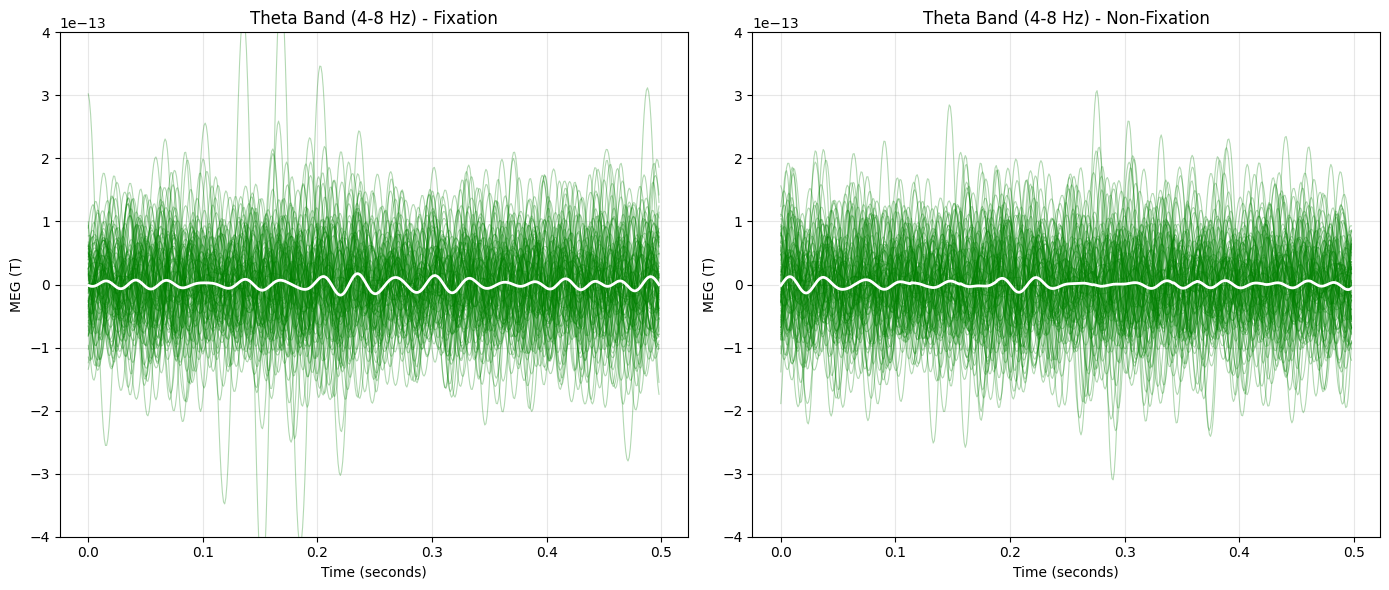

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixation
for seg in trimmed_fix:
    axes[0].plot(time_axis_fix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[0].plot(time_axis_fix, np.mean(trimmed_fix, axis=0), 'white', linewidth=2)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Theta Band (4-8 Hz) - Fixation')
axes[0].set_ylim(-4e-13, 4e-13)
axes[0].grid(True, alpha=0.3)

# Non-fixation
for seg in trimmed_nonfix:
    axes[1].plot(time_axis_nonfix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[1].plot(time_axis_nonfix, np.mean(trimmed_nonfix, axis=0), 'white', linewidth=2)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Theta Band (4-8 Hz) - Non-Fixation')
axes[1].set_ylim(-4e-13, 4e-13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### gamma

In [80]:
fixation_gamma = []
non_fixation_gamma = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    if start_idx < len(data_gamma) and stop_idx < len(data_gamma):
        fixation_gamma.append(data_gamma[start_idx:stop_idx])

for i in range(0, len(non_fix_idx), seg_len):
    end = min(i + seg_len, len(non_fix_idx))
    if end - i > 10:
        non_fixation_gamma.append(data_gamma[non_fix_idx[i:end]])

# Select 20 segments
fix_idx = np.random.choice(len(fixation_gamma), min(n_segments, len(fixation_gamma)), replace=False)
nonfix_idx = np.random.choice(len(non_fixation_gamma), min(n_segments, len(non_fixation_gamma)), replace=False)

# Fixation
min_len_fix = min([len(fixation_gamma[i]) for i in fix_idx])
time_axis_fix = np.arange(min_len_fix) / sfreq
trimmed_fix = [fixation_gamma[i][:min_len_fix] for i in fix_idx]

# Non-fixation
min_len_nonfix = min([len(non_fixation_gamma[i]) for i in nonfix_idx])
time_axis_nonfix = np.arange(min_len_nonfix) / sfreq
trimmed_nonfix = [non_fixation_gamma[i][:min_len_nonfix] for i in nonfix_idx]

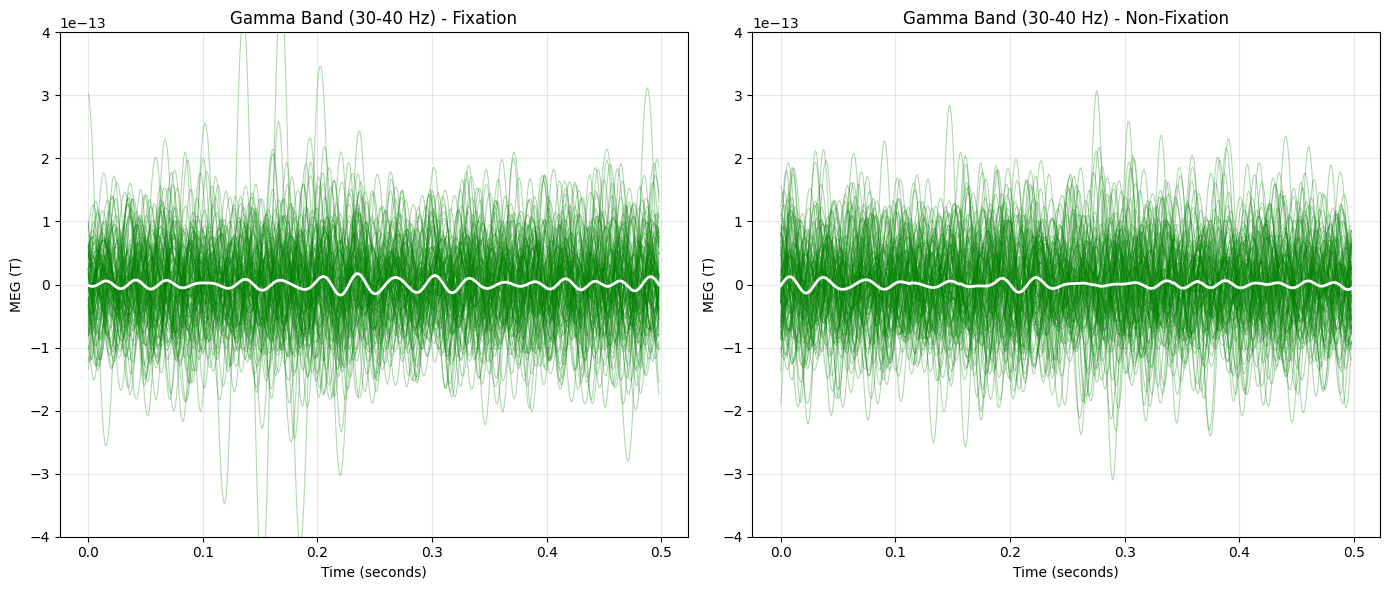

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixation
for seg in trimmed_fix:
    axes[0].plot(time_axis_fix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[0].plot(time_axis_fix, np.mean(trimmed_fix, axis=0), 'white', linewidth=2)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('MEG (T)')
axes[0].set_title('Gamma Band (30-40 Hz) - Fixation')
axes[0].set_ylim(-4e-13, 4e-13)
axes[0].grid(True, alpha=0.3)

# Non-fixation
for seg in trimmed_nonfix:
    axes[1].plot(time_axis_nonfix, seg, 'g-', alpha=0.3, linewidth=0.8)
axes[1].plot(time_axis_nonfix, np.mean(trimmed_nonfix, axis=0), 'white', linewidth=2)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('MEG (T)')
axes[1].set_title('Gamma Band (30-40 Hz) - Non-Fixation')
axes[1].set_ylim(-4e-13, 4e-13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# classification

## import again

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import coherence, welch
from scipy.stats import entropy
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Pick only magnetometers
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)
sfreq = raw.info['sfreq']

print(f"Using {len(mag_picks)} magnetometer channels")
print(f"Sampling frequency: {sfreq} Hz")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

## dataset

In [2]:
# Parameters
window_duration = 0.5  # seconds
window_samples = int(window_duration * sfreq)
step_samples = window_samples // 2  # 50% overlap

print(f"Window size: {window_samples} samples ({window_duration} seconds)")
print(f"Step size: {step_samples} samples")

# Create fixation windows
fixation_windows = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    # Convert to samples
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)

    # Slide window through fixation period
    for win_start in range(start_idx, stop_idx - window_samples + 1, step_samples):
        win_end = win_start + window_samples
        if win_end <= stop_idx:
            # Get data for all magnetometers
            window_data = raw_mag[:, win_start:win_end][0]
            fixation_windows.append(window_data)

print(f"Fixation windows created: {len(fixation_windows)}")

# Create mask of fixation periods for non-fixation sampling
fixation_mask = np.zeros(raw_mag.n_times, dtype=bool)
for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    fixation_mask[start_idx:stop_idx] = True

# Create non-fixation windows
non_fixation_windows = []

# Get all non-fixation indices
non_fix_indices = np.where(~fixation_mask)[0]

print(f"Total non-fixation samples: {len(non_fix_indices)}")

# Sample windows from non-fixation periods
for i in range(0, len(non_fix_indices) - window_samples, step_samples):
    win_start = non_fix_indices[i]
    win_end = win_start + window_samples

    if win_end < raw_mag.n_times:
        # Check if this window is completely in non-fixation
        if not np.any(fixation_mask[win_start:win_end]):
            window_data = raw_mag[:, win_start:win_end][0]
            non_fixation_windows.append(window_data)

            # Limit to reasonable number to avoid memory issues
            if len(non_fixation_windows) >= len(fixation_windows) * 3:
                break

print(f"Non-fixation windows created: {len(non_fixation_windows)}")

Window size: 500 samples (0.5 seconds)
Step size: 250 samples
Fixation windows created: 690
Total non-fixation samples: 2139118
Non-fixation windows created: 2070


In [3]:
# Balance classes (take equal number from both)
n_fix = len(fixation_windows)
n_nonfix = len(non_fixation_windows)
n_balanced = min(n_fix, n_nonfix)

print(f"\nFixation windows: {n_fix}")
print(f"Non-fixation windows: {n_nonfix}")
print(f"Balancing to: {n_balanced} windows each")

# Randomly sample from both classes
np.random.seed(42)
fix_idx = np.random.choice(n_fix, n_balanced, replace=False)
nonfix_idx = np.random.choice(n_nonfix, n_balanced, replace=False)

fixation_windows_balanced = [fixation_windows[i] for i in fix_idx]
non_fixation_windows_balanced = [non_fixation_windows[i] for i in nonfix_idx]

# Convert to numpy arrays
X_fix = np.array(fixation_windows_balanced)
X_nonfix = np.array(non_fixation_windows_balanced)

print(f"\nFixation windows shape: {X_fix.shape}")
print(f"Non-fixation windows shape: {X_nonfix.shape}")

# Create labels
y_fix = np.ones(len(X_fix))
y_nonfix = np.zeros(len(X_nonfix))

# Combine
X_all = np.concatenate([X_fix, X_nonfix], axis=0)
y_all = np.concatenate([y_fix, y_nonfix], axis=0)

print(f"\nTotal samples: {len(X_all)}")
print(f"Class 1 (Fixation): {sum(y_all==1)}")
print(f"Class 0 (Non-fixation): {sum(y_all==0)}")


Fixation windows: 690
Non-fixation windows: 2070
Balancing to: 690 windows each

Fixation windows shape: (690, 102, 500)
Non-fixation windows shape: (690, 102, 500)

Total samples: 1380
Class 1 (Fixation): 690
Class 0 (Non-fixation): 690


## features

In [4]:
from scipy.signal import welch, butter, filtfilt

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

def compute_psd_batch(windows, sfreq):
    freqs, psd = welch(
        windows,
        fs=sfreq,
        nperseg=int(sfreq*2),
        axis=2
    )
    return freqs, psd

def bandpower_from_psd(freqs, psd):
    total_power = np.trapezoid(psd, freqs, axis=2)
    feats = []

    for low, high in bands.values():
        idx = (freqs >= low) & (freqs <= high)
        band_power = np.trapezoid(psd[:, :, idx], freqs[idx], axis=2)
        feats.append(band_power / (total_power + 1e-10))

    return np.concatenate(feats, axis=1)

def bandpass(data, sfreq, low, high):
    b, a = butter(4, [low/(sfreq/2), high/(sfreq/2)], btype='band')
    return filtfilt(b, a, data, axis=1)

def fast_connectivity(window):
    corr = np.corrcoef(window)
    return corr[np.triu_indices_from(corr, k=1)]

def coherence_band_fast(window, sfreq, band):
    filtered = bandpass(window, sfreq, band[0], band[1])
    return fast_connectivity(filtered)

In [5]:
import time
import numpy as np
from scipy.stats import entropy

# ============================================================================
# Permutation Entropy
# ============================================================================
def permutation_entropy(signal, m=3, delay=1):
    from math import factorial
    n_patterns = factorial(m)
    patterns = np.zeros(n_patterns)

    for i in range(len(signal) - (m-1)*delay):
        idx = 0
        pattern = np.argsort([signal[i + k*delay] for k in range(m)])
        for j, r in enumerate(pattern):
            idx += r * (n_patterns // (m - j)) if m - j > 0 else 0
        patterns[idx % n_patterns] += 1

    probs = patterns / (patterns.sum() + 1e-10)
    return -np.sum(probs * np.log(probs + 1e-10)) / np.log(n_patterns)

# ============================================================================
# Sample Entropy
# ============================================================================
def sample_entropy(signal, m=2, r=0.2):
    signal = signal - np.mean(signal)
    r = r * np.std(signal)
    N = len(signal)

    if N < m + 1 or r == 0:
        return 0

    templates_m = np.array([signal[i:i+m] for i in range(N-m+1)])
    templates_m1 = np.array([signal[i:i+m+1] for i in range(N-m)])

    B = sum([np.sum(np.max(np.abs(templates_m - t), axis=1) <= r) - 1 for t in templates_m])
    A = sum([np.sum(np.max(np.abs(templates_m1 - t), axis=1) <= r) - 1 for t in templates_m1])

    B = B / len(templates_m) if len(templates_m) > 0 else 0
    A = A / len(templates_m1) if len(templates_m1) > 0 else 0

    return -np.log(A / B) if A > 0 and B > 0 else 0

In [108]:
window = X_all[0, 0, :]

In [109]:
start = time.time()
pe = permutation_entropy(window)
print(f"Permutation entropy: {pe:.4f} | Time: {time.time()-start:.4f}s")

# Test sample entropy
start = time.time()
se = sample_entropy(window)
print(f"Sample entropy: {se:.4f} | Time: {time.time()-start:.4f}s")

Permutation entropy: 0.5247 | Time: 0.0064s
Sample entropy: 0.2199 | Time: 0.0202s


In [6]:
def spectral_entropy(psd):
    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-10)
    return -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=-1)

def hjorth_params(signal):
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var0 = np.var(signal)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-10))
    complexity = np.sqrt(var2 / (var1 + 1e-10)) / (mobility + 1e-10)

    return np.array([activity, mobility, complexity])

In [7]:
def add_coordinate_features(raw_info, window):
    mag_picks = mne.pick_types(raw_info, meg='mag')
    positions = np.array([raw_info['chs'][i]['loc'][:3] for i in mag_picks])

    # Activity per channel
    activity = np.mean(window**2, axis=1)
    activity /= (np.sum(activity) + 1e-10)

    center = np.sum(positions * activity[:, None], axis=0)
    spread = np.sum(((positions - center)**2) * activity[:, None], axis=0)

    return np.concatenate([center, spread])

In [10]:
# ======================
# Fast feature extraction for all bands
# ======================
def extract_features_fast(windows, raw_info, sfreq):
    """
    windows: array (n_windows, n_channels, n_times)
    raw_info: MNE Raw.info
    sfreq: sampling frequency
    """
    # --- Precompute PSD for all windows ---
    freqs, psd = compute_psd_batch(windows, sfreq)  # shape: (n_windows, n_channels, n_freqs)
    n_windows, n_channels, n_times = windows.shape

    # --- Bandpower features ---
    bp = bandpower_from_psd(freqs, psd)  # returns (n_windows, n_channels * n_bands)

    # --- Spectral entropy per channel ---
    ent = spectral_entropy(psd)  # (n_windows, n_channels)

    # --- Connectivity for all bands ---
    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    # --- Permutation entropy per channel ---
    # perm_ent = np.array([[permutation_entropy(windows[i, ch, :]) for ch in range(n_channels)] for i in range(n_windows)])
    #
    # # --- Sample entropy per channel ---
    # samp_ent = np.array([[sample_entropy(windows[i, ch, :]) for ch in range(n_channels)] for i in range(n_windows)])

    conn_features = []
    for band_name, band_range in bands_list.items():
        # Compute coherence for this band for each window
        conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
        conn_features.append(conn_band)
    conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)

    # --- Hjorth parameters per channel ---
    hjorth_feats = np.array([
        np.concatenate([hjorth_params(ch) for ch in w])
        for w in windows
    ])  # shape: (n_windows, n_channels*3)

    # --- Coordinate / spatial features ---
    coord_feats = np.array([add_coordinate_features(raw_info, w) for w in windows])  # (n_windows, n_coord)

    # --- Combine all ---
    X = np.concatenate([bp, ent,
                        # perm_ent, samp_ent,
                        conn_all, hjorth_feats, coord_feats], axis=1)
    return X

## train test split

In [11]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Extract features
print("\nExtracting features from training set...")
X_train_feat = extract_features_fast(X_train, raw.info, sfreq)
print(f"Train features shape: {X_train_feat.shape}")

print("\nExtracting features from test set...")
X_test_feat = extract_features_fast(X_test, raw.info, sfreq)
print(f"Test features shape: {X_test_feat.shape}")

Train set: 1104 samples
Test set: 276 samples

Extracting features from training set...
Train features shape: (1104, 26679)

Extracting features from test set...
Test features shape: (276, 26679)


In [12]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.float64(0.0): 552, np.float64(1.0): 552})


## model

In [13]:
# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Train model
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost model...")
model.fit(X_train_feat, y_train)

# Predictions
preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:, 1]

# Results
print("\n" + "="*60)
print("XGBOOST CLASSIFICATION RESULTS")
print("="*60)
print(classification_report(y_test, preds, target_names=['Non-Fixation', 'Fixation']))
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")

Training XGBoost model...

XGBOOST CLASSIFICATION RESULTS
              precision    recall  f1-score   support

Non-Fixation       0.76      0.88      0.81       138
    Fixation       0.85      0.72      0.78       138

    accuracy                           0.80       276
   macro avg       0.81      0.80      0.80       276
weighted avg       0.81      0.80      0.80       276

ROC AUC: 0.8872


## results

using these features:
 ```
    X = np.concatenate([bp, ent, conn_all, hjorth_feats, coord_feats], axis=1)
```
foloowing results:
```
    XGBOOST CLASSIFICATION RESULTS
                  precision    recall  f1-score   support

    Non-Fixation       0.76      0.88      0.81       138
        Fixation       0.85      0.72      0.78       138

        accuracy                           0.80       276
       macro avg       0.81      0.80      0.80       276
    weighted avg       0.81      0.80      0.80       276

    ROC AUC: 0.8872
```

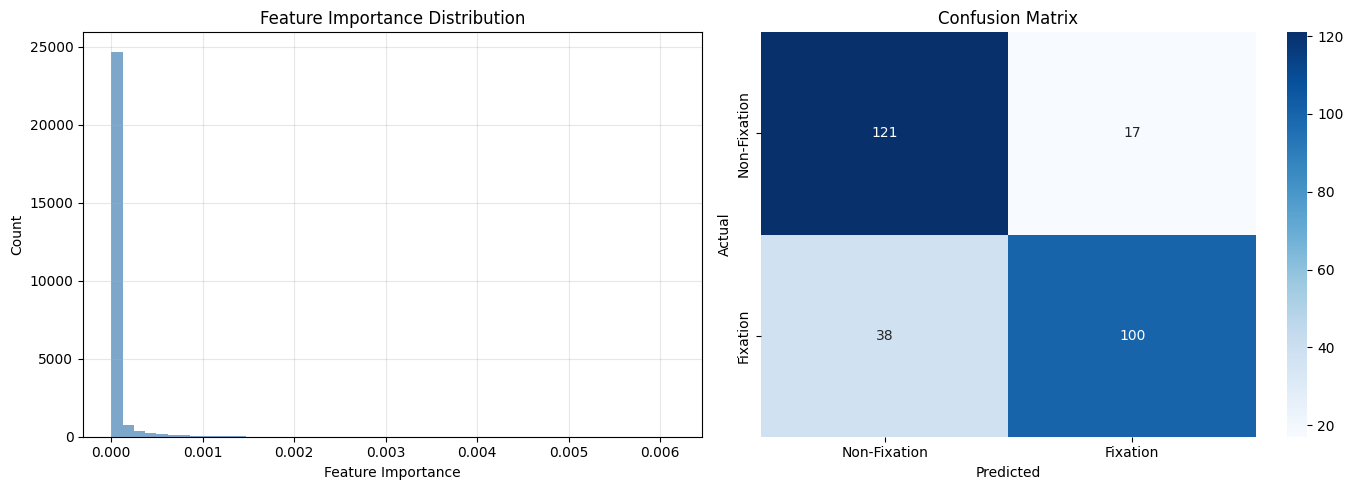


Model Accuracy: 0.8007


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Feature importance
feature_importance = model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance distribution
axes[0].hist(feature_importance, bins=50, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Feature Importance')
axes[0].set_ylabel('Count')
axes[0].set_title('Feature Importance Distribution')
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fixation', 'Fixation'],
            yticklabels=['Non-Fixation', 'Fixation'],
            ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print(f"\nModel Accuracy: {model.score(X_test_feat, y_test):.4f}")

## feature importances

In [14]:
importances = model.feature_importances_
print(f"Number of features: {len(importances)}")
print(f"Feature importance range: {importances.min():.6f} to {importances.max():.6f}")
print(f"Total importance sum: {importances.sum():.4f}")

Number of features: 26679
Feature importance range: 0.000000 to 0.006154
Total importance sum: 1.0000


In [15]:
# Calculate feature groupings
n_channels = X_all.shape[1]
n_bands = 5  # delta, theta, alpha, beta, gamma

# Feature indices based on extract_features_fast order:
# 1. Bandpower features: n_channels * n_bands
# 2. Spectral entropy: n_channels
# 3. Connectivity: n_conn_features
# 4. Hjorth parameters: n_channels * 2 (mobility + complexity)
# 5. Coordinate features: 4 (mean, std, max, min)

bp_start = 0
bp_end = n_channels * n_bands
ent_start = bp_end
ent_end = ent_start + n_channels
conn_start = ent_end
conn_end = conn_start + X_train_feat.shape[1] - (bp_end + n_channels + (n_channels * 2) + 4)
hjorth_start = conn_end
hjorth_end = hjorth_start + (n_channels * 2)
coord_start = hjorth_end
coord_end = coord_start + 4

print("Feature Group Ranges:")
print(f"Bandpower features: {bp_start}-{bp_end-1} ({bp_end-bp_start} features)")
print(f"Spectral entropy: {ent_start}-{ent_end-1} ({ent_end-ent_start} features)")
print(f"Connectivity features: {conn_start}-{conn_end-1} ({conn_end-conn_start} features)")
print(f"Hjorth parameters: {hjorth_start}-{hjorth_end-1} ({hjorth_end-hjorth_start} features)")
print(f"Coordinate features: {coord_start}-{coord_end-1} ({coord_end-coord_start} features)")

# Calculate importance per group
group_importance = {
    'Bandpower': np.sum(importances[bp_start:bp_end]),
    'Spectral Entropy': np.sum(importances[ent_start:ent_end]),
    'Connectivity': np.sum(importances[conn_start:conn_end]),
    'Hjorth': np.sum(importances[hjorth_start:hjorth_end]),
    'Coordinate': np.sum(importances[coord_start:coord_end])
}

print("\nTotal Importance per Feature Group:")
for group, imp in sorted(group_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {group}: {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

Feature Group Ranges:
Bandpower features: 0-509 (510 features)
Spectral entropy: 510-611 (102 features)
Connectivity features: 612-26470 (25859 features)
Hjorth parameters: 26471-26674 (204 features)
Coordinate features: 26675-26678 (4 features)

Total Importance per Feature Group:
  Connectivity: 0.9021 (90.2%)
  Bandpower: 0.0483 (4.8%)
  Hjorth: 0.0431 (4.3%)
  Spectral Entropy: 0.0065 (0.7%)
  Coordinate: 0.0000 (0.0%)


In [16]:
# Get top 20 features
top_n = 20
top_indices = np.argsort(importances)[-top_n:][::-1]
top_importances = importances[top_indices]

# Map indices to feature names
feature_names = []

# Bandpower features
bands_order = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for ch in range(n_channels):
    for band in bands_order:
        feature_names.append(f'Bandpower_ch{ch}_{band}')

# Spectral entropy
for ch in range(n_channels):
    feature_names.append(f'SpectralEntropy_ch{ch}')

# Connectivity features
for i in range(conn_end - conn_start):
    feature_names.append(f'Connectivity_{i}')

# Hjorth features
for ch in range(n_channels):
    feature_names.append(f'Hjorth_mobility_ch{ch}')
    feature_names.append(f'Hjorth_complexity_ch{ch}')

# Coordinate features
coord_names = ['Mean', 'Std', 'Max', 'Min']
for name in coord_names:
    feature_names.append(f'Coordinate_{name}')

# Print top features
print(f"Top {top_n} Most Important Features:")
print("="*70)
for i, (idx, imp) in enumerate(zip(top_indices, top_importances)):
    print(f"{i+1:2d}. {imp:.6f} - {feature_names[idx]}")

Top 20 Most Important Features:
 1. 0.006154 - Hjorth_mobility_ch67
 2. 0.004117 - Bandpower_ch100_beta
 3. 0.003669 - Bandpower_ch97_alpha
 4. 0.003093 - Hjorth_mobility_ch91
 5. 0.003085 - Hjorth_complexity_ch89
 6. 0.002568 - Connectivity_18097
 7. 0.002522 - Connectivity_200
 8. 0.002492 - Connectivity_22448
 9. 0.002346 - Connectivity_582
10. 0.002267 - Connectivity_22607
11. 0.002264 - Connectivity_6097
12. 0.002197 - Connectivity_7457
13. 0.002189 - Connectivity_20329
14. 0.002180 - SpectralEntropy_ch93
15. 0.002168 - Connectivity_18448
16. 0.002089 - Hjorth_mobility_ch94
17. 0.001980 - Connectivity_8972
18. 0.001880 - Connectivity_17260
19. 0.001864 - Connectivity_18588
20. 0.001802 - Connectivity_5101


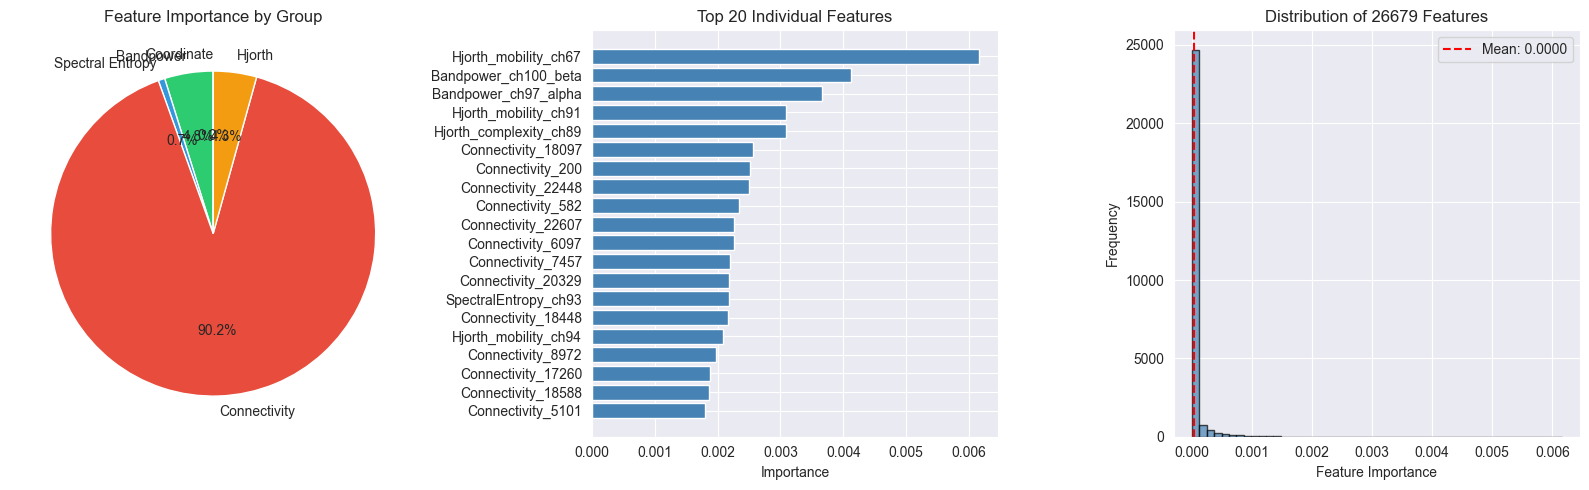


Model Performance:
Accuracy: 0.8007
ROC AUC: 0.8872

Classification Report:
              precision    recall  f1-score   support

Non-Fixation       0.76      0.88      0.81       138
    Fixation       0.85      0.72      0.78       138

    accuracy                           0.80       276
   macro avg       0.81      0.80      0.80       276
weighted avg       0.81      0.80      0.80       276



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Group importance pie chart
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
axes[0].pie(group_importance.values(), labels=group_importance.keys(),
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Feature Importance by Group')

# Plot 2: Top 20 features
axes[1].barh(range(top_n), top_importances[::-1], color='steelblue')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feature_names[i][:30] for i in top_indices[::-1]])
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Top {top_n} Individual Features')

# Plot 3: Distribution of feature importances
axes[2].hist(importances, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[2].set_xlabel('Feature Importance')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Distribution of {len(importances)} Features')
axes[2].axvline(np.mean(importances), color='red', linestyle='--', label=f'Mean: {np.mean(importances):.4f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print model performance
preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:, 1]
print("\nModel Performance:")
print(f"Accuracy: {model.score(X_test_feat, y_test):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Non-Fixation', 'Fixation']))

In [18]:
# Get actual magnetometer channel names
channel_names = raw_mag.info['ch_names']
n_channels = len(channel_names)
n_bands = 5  # delta, theta, alpha, beta, gamma

print(f"Channel names (first 5): {channel_names[:5]}")
print(f"Total channels: {n_channels}")

# Feature indices based on extract_features_fast order:
# 1. Bandpower features: n_channels * n_bands
# 2. Spectral entropy: n_channels
# 3. Connectivity features: variable
# 4. Hjorth parameters: n_channels * 2
# 5. Coordinate features: 4

bp_end = n_channels * n_bands
ent_end = bp_end + n_channels

# Calculate connectivity feature count (from your actual extraction)
conn_count = X_train_feat.shape[1] - (bp_end + n_channels + (n_channels * 2) + 4)
conn_end = ent_end + conn_count
hjorth_end = conn_end + (n_channels * 2)
coord_end = hjorth_end + 4

print(f"\nFeature counts:")
print(f"Bandpower: {bp_end}")
print(f"Spectral entropy: {n_channels}")
print(f"Connectivity: {conn_count}")
print(f"Hjorth: {n_channels * 2}")
print(f"Coordinate: 4")

Channel names (first 5): ['MEG0111', 'MEG0121', 'MEG0131', 'MEG0141', 'MEG0211']
Total channels: 102

Feature counts:
Bandpower: 510
Spectral entropy: 102
Connectivity: 25859
Hjorth: 204
Coordinate: 4


In [19]:
# Create feature names with actual channel names
feature_names = []

# 1. Bandpower features (n_channels * n_bands)
bands_order = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for ch_name in channel_names:
    for band in bands_order:
        feature_names.append(f'Bandpower_{ch_name}_{band}')

# 2. Spectral entropy
for ch_name in channel_names:
    feature_names.append(f'SpectralEntropy_{ch_name}')

# 3. Connectivity features
for i in range(conn_count):
    feature_names.append(f'Connectivity_{i}')

# 4. Hjorth features
for ch_name in channel_names:
    feature_names.append(f'Hjorth_mobility_{ch_name}')
    feature_names.append(f'Hjorth_complexity_{ch_name}')

# 5. Coordinate features
coord_names = ['Mean', 'Std', 'Max', 'Min']
for name in coord_names:
    feature_names.append(f'Coordinate_{name}')

print(f"Total feature names created: {len(feature_names)}")
print(f"\nExample feature names:")
for i in range(10):
    print(f"  {feature_names[i]}")

Total feature names created: 26679

Example feature names:
  Bandpower_MEG0111_delta
  Bandpower_MEG0111_theta
  Bandpower_MEG0111_alpha
  Bandpower_MEG0111_beta
  Bandpower_MEG0111_gamma
  Bandpower_MEG0121_delta
  Bandpower_MEG0121_theta
  Bandpower_MEG0121_alpha
  Bandpower_MEG0121_beta
  Bandpower_MEG0121_gamma


In [20]:
# Get top 20 features
top_n = 20
top_indices = np.argsort(importances)[-top_n:][::-1]
top_importances = importances[top_indices]

print(f"\nTop {top_n} Most Important Features:")
print("="*80)
for i, (idx, imp) in enumerate(zip(top_indices, top_importances)):
    # Truncate long names for display
    name = feature_names[idx]
    if len(name) > 50:
        name = name[:47] + "..."
    print(f"{i+1:2d}. {imp:.6f} - {name}")


Top 20 Most Important Features:
 1. 0.006154 - Hjorth_mobility_MEG1821
 2. 0.004117 - Bandpower_MEG2631_beta
 3. 0.003669 - Bandpower_MEG2541_alpha
 4. 0.003093 - Hjorth_mobility_MEG2421
 5. 0.003085 - Hjorth_complexity_MEG2341
 6. 0.002568 - Connectivity_18097
 7. 0.002522 - Connectivity_200
 8. 0.002492 - Connectivity_22448
 9. 0.002346 - Connectivity_582
10. 0.002267 - Connectivity_22607
11. 0.002264 - Connectivity_6097
12. 0.002197 - Connectivity_7457
13. 0.002189 - Connectivity_20329
14. 0.002180 - SpectralEntropy_MEG2441
15. 0.002168 - Connectivity_18448
16. 0.002089 - Hjorth_mobility_MEG2511
17. 0.001980 - Connectivity_8972
18. 0.001880 - Connectivity_17260
19. 0.001864 - Connectivity_18588
20. 0.001802 - Connectivity_5101


In [21]:
# Calculate importance per group
group_importance = {
    'Bandpower': np.sum(importances[:bp_end]),
    'Spectral Entropy': np.sum(importances[bp_end:ent_end]),
    'Connectivity': np.sum(importances[ent_end:conn_end]),
    'Hjorth': np.sum(importances[conn_end:hjorth_end]),
    'Coordinate': np.sum(importances[hjorth_end:coord_end])
}

print("Feature Importance by Group:")
print("="*50)
for group, imp in sorted(group_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{group:16s}: {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

# Find most important channel for each band
if group_importance['Bandpower'] > 0:
    print("\n" + "="*50)
    print("Top Channel by Frequency Band:")
    print("="*50)

    for b, band in enumerate(bands_order):
        band_start = b * n_channels
        band_end = (b + 1) * n_channels
        band_importances = importances[band_start:band_end]
        top_ch_idx = np.argmax(band_importances)
        print(f"{band:8s}: {channel_names[top_ch_idx]} (importance: {band_importances[top_ch_idx]:.6f})")

Feature Importance by Group:
Connectivity    : 0.9021 (90.2%)
Bandpower       : 0.0483 (4.8%)
Hjorth          : 0.0431 (4.3%)
Spectral Entropy: 0.0065 (0.7%)
Coordinate      : 0.0000 (0.0%)

Top Channel by Frequency Band:
delta   : MEG2211 (importance: 0.000732)
theta   : MEG2031 (importance: 0.001090)
alpha   : MEG0741 (importance: 0.000895)
beta    : MEG2331 (importance: 0.000761)
gamma   : MEG2521 (importance: 0.004117)


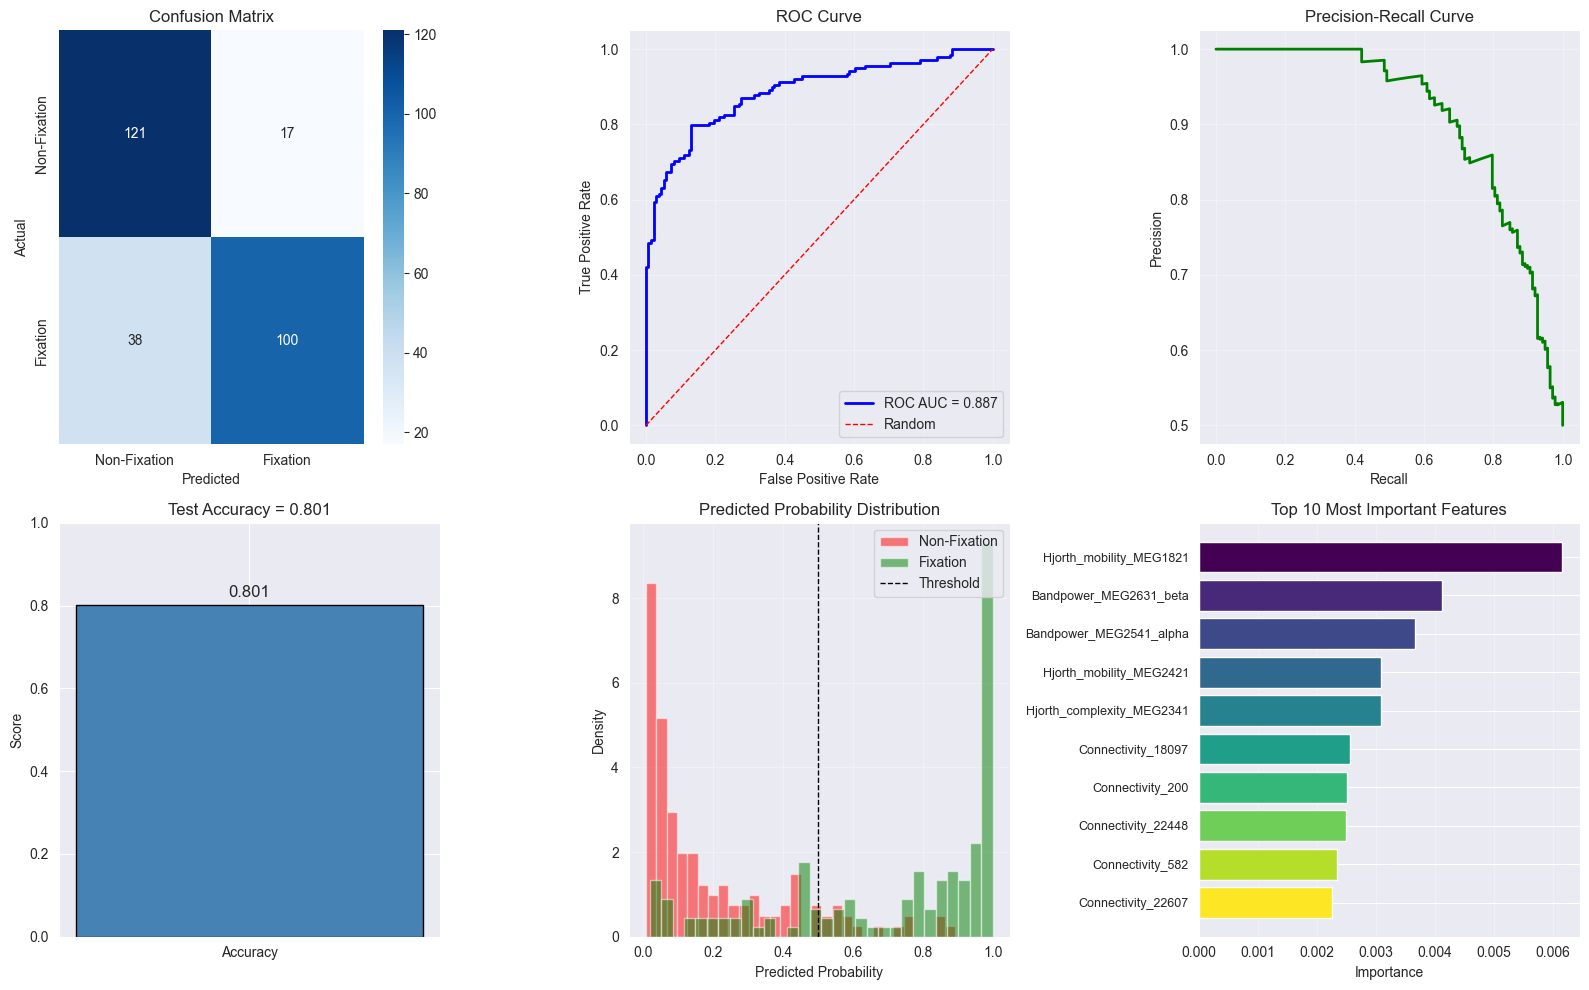

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import numpy as np

# Model predictions
preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:, 1]

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fixation', 'Fixation'],
            yticklabels=['Non-Fixation', 'Fixation'],
            ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = plt.subplot(2, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, probs)
ax3.plot(recall, precision, 'g-', linewidth=2)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.grid(True, alpha=0.3)

# 4. Accuracy Bar Plot
ax4 = plt.subplot(2, 3, 4)
accuracy = model.score(X_test_feat, y_test)
ax4.bar(['Accuracy'], [accuracy], color='steelblue', edgecolor='black')
ax4.set_ylim([0, 1])
ax4.set_ylabel('Score')
ax4.set_title(f'Test Accuracy = {accuracy:.3f}')
ax4.text(0, accuracy + 0.02, f'{accuracy:.3f}', ha='center', fontsize=12)

# 5. Probability Distribution
ax5 = plt.subplot(2, 3, 5)
fix_probs = probs[y_test == 1]
nonfix_probs = probs[y_test == 0]
ax5.hist(nonfix_probs, bins=30, alpha=0.5, label='Non-Fixation', color='red', density=True)
ax5.hist(fix_probs, bins=30, alpha=0.5, label='Fixation', color='green', density=True)
ax5.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Density')
ax5.set_title('Predicted Probability Distribution')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Feature Importance Summary
ax6 = plt.subplot(2, 3, 6)
# Get top 10 features
top10_idx = np.argsort(importances)[-10:][::-1]
top10_names = [feature_names[i][:25] + '...' if len(feature_names[i]) > 25 else feature_names[i]
               for i in top10_idx]
top10_imps = importances[top10_idx]
colors = plt.cm.viridis(np.linspace(0, 1, 10))
ax6.barh(range(10), top10_imps[::-1], color=colors[::-1])
ax6.set_yticks(range(10))
ax6.set_yticklabels(top10_names[::-1], fontsize=9)
ax6.set_xlabel('Importance')
ax6.set_title('Top 10 Most Important Features')
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# classification on one channel

## import

In [25]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import coherence, welch
from scipy.stats import entropy
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Pick only magnetometers
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks[0])
sfreq = raw.info['sfreq']

print(f"Using {len(mag_picks)} magnetometer channels")
print(f"Sampling frequency: {sfreq} Hz")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

## dataset

In [26]:
# Parameters
window_duration = 0.5  # seconds
window_samples = int(window_duration * sfreq)
step_samples = window_samples // 2  # 50% overlap

print(f"Window size: {window_samples} samples ({window_duration} seconds)")
print(f"Step size: {step_samples} samples")

# Create fixation windows
fixation_windows = []

for start, stop in zip(fix_cross_start, fix_cross_stop):
    # Convert to samples
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)

    # Slide window through fixation period
    for win_start in range(start_idx, stop_idx - window_samples + 1, step_samples):
        win_end = win_start + window_samples
        if win_end <= stop_idx:
            # Get data for all magnetometers
            window_data = raw_mag[:, win_start:win_end][0]
            fixation_windows.append(window_data)

print(f"Fixation windows created: {len(fixation_windows)}")

# Create mask of fixation periods for non-fixation sampling
fixation_mask = np.zeros(raw_mag.n_times, dtype=bool)
for start, stop in zip(fix_cross_start, fix_cross_stop):
    start_idx = int(start * sfreq)
    stop_idx = int(stop * sfreq)
    fixation_mask[start_idx:stop_idx] = True

# Create non-fixation windows
non_fixation_windows = []

# Get all non-fixation indices
non_fix_indices = np.where(~fixation_mask)[0]

print(f"Total non-fixation samples: {len(non_fix_indices)}")

# Sample windows from non-fixation periods
for i in range(0, len(non_fix_indices) - window_samples, step_samples):
    win_start = non_fix_indices[i]
    win_end = win_start + window_samples

    if win_end < raw_mag.n_times:
        # Check if this window is completely in non-fixation
        if not np.any(fixation_mask[win_start:win_end]):
            window_data = raw_mag[:, win_start:win_end][0]
            non_fixation_windows.append(window_data)

            # Limit to reasonable number to avoid memory issues
            if len(non_fixation_windows) >= len(fixation_windows) * 3:
                break

print(f"Non-fixation windows created: {len(non_fixation_windows)}")

Window size: 500 samples (0.5 seconds)
Step size: 250 samples
Fixation windows created: 690
Total non-fixation samples: 2139118
Non-fixation windows created: 2070


In [27]:
# Balance classes (take equal number from both)
n_fix = len(fixation_windows)
n_nonfix = len(non_fixation_windows)
n_balanced = min(n_fix, n_nonfix)

print(f"\nFixation windows: {n_fix}")
print(f"Non-fixation windows: {n_nonfix}")
print(f"Balancing to: {n_balanced} windows each")

# Randomly sample from both classes
np.random.seed(42)
fix_idx = np.random.choice(n_fix, n_balanced, replace=False)
nonfix_idx = np.random.choice(n_nonfix, n_balanced, replace=False)

fixation_windows_balanced = [fixation_windows[i] for i in fix_idx]
non_fixation_windows_balanced = [non_fixation_windows[i] for i in nonfix_idx]

# Convert to numpy arrays
X_fix = np.array(fixation_windows_balanced)
X_nonfix = np.array(non_fixation_windows_balanced)

print(f"\nFixation windows shape: {X_fix.shape}")
print(f"Non-fixation windows shape: {X_nonfix.shape}")

# Create labels
y_fix = np.ones(len(X_fix))
y_nonfix = np.zeros(len(X_nonfix))

# Combine
X_all = np.concatenate([X_fix, X_nonfix], axis=0)
y_all = np.concatenate([y_fix, y_nonfix], axis=0)

print(f"\nTotal samples: {len(X_all)}")
print(f"Class 1 (Fixation): {sum(y_all==1)}")
print(f"Class 0 (Non-fixation): {sum(y_all==0)}")


Fixation windows: 690
Non-fixation windows: 2070
Balancing to: 690 windows each

Fixation windows shape: (690, 1, 500)
Non-fixation windows shape: (690, 1, 500)

Total samples: 1380
Class 1 (Fixation): 690
Class 0 (Non-fixation): 690


## features

In [30]:
# ======================
# Fast feature extraction for all bands
# ======================
def extract_features_fast(windows, raw_info, sfreq):
    """
    windows: array (n_windows, n_channels, n_times)
    raw_info: MNE Raw.info
    sfreq: sampling frequency
    """
    # --- Precompute PSD for all windows ---
    freqs, psd = compute_psd_batch(windows, sfreq)  # shape: (n_windows, n_channels, n_freqs)
    n_windows, n_channels, n_times = windows.shape

    # --- Bandpower features ---
    bp = bandpower_from_psd(freqs, psd)  # returns (n_windows, n_channels * n_bands)

    # --- Spectral entropy per channel ---
    ent = spectral_entropy(psd)  # (n_windows, n_channels)

    # --- Connectivity for all bands ---
    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    # --- Permutation entropy per channel ---
    perm_ent = np.array([[permutation_entropy(windows[i, ch, :]) for ch in range(n_channels)] for i in range(n_windows)])

    # --- Sample entropy per channel ---
    samp_ent = np.array([[sample_entropy(windows[i, ch, :]) for ch in range(n_channels)] for i in range(n_windows)])

    # conn_features = []
    # for band_name, band_range in bands_list.items():
    #     # Compute coherence for this band for each window
    #     conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
    #     conn_features.append(conn_band)
    # conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)

    # --- Hjorth parameters per channel ---
    hjorth_feats = np.array([
        np.concatenate([hjorth_params(ch) for ch in w])
        for w in windows
    ])  # shape: (n_windows, n_channels*3)

    # --- Coordinate / spatial features ---
    coord_feats = np.array([add_coordinate_features(raw_info, w) for w in windows])  # (n_windows, n_coord)

    # --- Combine all ---
    X = np.concatenate([bp, ent,
                        perm_ent, samp_ent,
                        # conn_all,
                        hjorth_feats, coord_feats], axis=1)
    return X

## train test split

In [31]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Extract features
print("\nExtracting features from training set...")
X_train_feat = extract_features_fast(X_train, raw.info, sfreq)
print(f"Train features shape: {X_train_feat.shape}")

print("\nExtracting features from test set...")
X_test_feat = extract_features_fast(X_test, raw.info, sfreq)
print(f"Test features shape: {X_test_feat.shape}")

Train set: 1104 samples
Test set: 276 samples

Extracting features from training set...
Train features shape: (1104, 17)

Extracting features from test set...
Test features shape: (276, 17)


In [32]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.float64(0.0): 552, np.float64(1.0): 552})


## model

In [33]:
# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Train model
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost model...")
model.fit(X_train_feat, y_train)

# Predictions
preds = model.predict(X_test_feat)
probs = model.predict_proba(X_test_feat)[:, 1]

# Results
print("\n" + "="*60)
print("XGBOOST CLASSIFICATION RESULTS")
print("="*60)
print(classification_report(y_test, preds, target_names=['Non-Fixation', 'Fixation']))
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")

Training XGBoost model...

XGBOOST CLASSIFICATION RESULTS
              precision    recall  f1-score   support

Non-Fixation       0.55      0.52      0.54       138
    Fixation       0.54      0.57      0.56       138

    accuracy                           0.55       276
   macro avg       0.55      0.55      0.55       276
weighted avg       0.55      0.55      0.55       276

ROC AUC: 0.5507


# classification with frontal channels

In [47]:
fnam1e = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw1 = mne.io.read_raw_fif(fnam1e, preload=True)

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [48]:
montage = raw1.get_montage()
montage

<DigMontage | 154 extras (headshape), 4 HPIs, 3 fiducials, 0 channels>

In [ ]:
montage

In [46]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import coherence, welch
from scipy.stats import entropy
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Pick only magnetometers
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks[0])
sfreq = raw.info['sfreq']

print(f"Using {len(mag_picks)} magnetometer channels")
print(f"Sampling frequency: {sfreq} Hz")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [34]:
# Load the digitized head points/channel positions
if raw.info['dig'] is not None:
    # Get channel positions
    montage = raw.get_montage()

    if montage is not None:
        # Get channel positions
        ch_positions = montage.get_positions()
        ch_loc = ch_positions['ch_pos']

        # Find frontal channels (y > 0 typically for frontal, depending on coordinate system)
        frontal_channels = []
        for ch_name, pos in ch_loc.items():
            if 'MEG' in ch_name:
                # In Neuromag coordinate system:
                # x: left-right (positive right)
                # y: anterior-posterior (positive anterior/front)
                # z: superior-inferior (positive up)
                y_pos = pos[1]  # y-coordinate
                if y_pos > 0.02:  # Threshold for frontal (adjust as needed)
                    frontal_channels.append(ch_name)

        print(f"Found {len(frontal_channels)} frontal channels by coordinates:")
        print(frontal_channels[:10])

Found 0 frontal channels by coordinates:
[]


In [35]:
# Common MEG frontal channel naming patterns
# For Neuromag/Elekta/MEGIN systems, frontal channels often start with:
# - MEG01xx, MEG02xx (anterior frontal)
# - MEG03xx, MEG04xx (frontal)
# - MEG05xx (central frontal)

frontal_patterns = ['MEG01', 'MEG02', 'MEG03', 'MEG04', 'MEG05']

# Get all channel names
all_mag_names = [ch for ch in raw.ch_names if 'MEG' in ch]

# Select frontal channels by name pattern
frontal_channels = []
for ch in all_mag_names:
    # Extract the 3-digit number after MEG (e.g., MEG0111 -> 011)
    ch_num = ch[3:6]  # Gets '011' from 'MEG0111'
    if ch_num.startswith('0'):
        # Frontal channels typically have numbers 01-05
        if int(ch_num[1:3]) <= 5:  # 01-05 range
            frontal_channels.append(ch)

print(f"Found {len(frontal_channels)} frontal channels by naming:")
print(frontal_channels[:10])

Found 0 frontal channels by naming:
[]


In [43]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<Raw | main.fif, 324 x 2543000 (2543.0 s), ~6.14 GiB, data loaded>

In [44]:
print(raw.ch_names)


['MEG0113', 'MEG0112', 'MEG0111', 'MEG0122', 'MEG0123', 'MEG0121', 'MEG0132', 'MEG0133', 'MEG0131', 'MEG0143', 'MEG0142', 'MEG0141', 'MEG0213', 'MEG0212', 'MEG0211', 'MEG0222', 'MEG0223', 'MEG0221', 'MEG0232', 'MEG0233', 'MEG0231', 'MEG0243', 'MEG0242', 'MEG0241', 'MEG0313', 'MEG0312', 'MEG0311', 'MEG0322', 'MEG0323', 'MEG0321', 'MEG0333', 'MEG0332', 'MEG0331', 'MEG0343', 'MEG0342', 'MEG0341', 'MEG0413', 'MEG0412', 'MEG0411', 'MEG0422', 'MEG0423', 'MEG0421', 'MEG0432', 'MEG0433', 'MEG0431', 'MEG0443', 'MEG0442', 'MEG0441', 'MEG0513', 'MEG0512', 'MEG0511', 'MEG0523', 'MEG0522', 'MEG0521', 'MEG0532', 'MEG0533', 'MEG0531', 'MEG0542', 'MEG0543', 'MEG0541', 'MEG0613', 'MEG0612', 'MEG0611', 'MEG0622', 'MEG0623', 'MEG0621', 'MEG0633', 'MEG0632', 'MEG0631', 'MEG0642', 'MEG0643', 'MEG0641', 'MEG0713', 'MEG0712', 'MEG0711', 'MEG0723', 'MEG0722', 'MEG0721', 'MEG0733', 'MEG0732', 'MEG0731', 'MEG0743', 'MEG0742', 'MEG0741', 'MEG0813', 'MEG0812', 'MEG0811', 'MEG0822', 'MEG0823', 'MEG0821', 'MEG0913'

In [45]:
# Load the digitized head points/channel positions
if raw.info['dig'] is not None:
    # Get channel positions
    montage = raw.get_montage()

    if montage is not None:
        # Get channel positions
        ch_positions = montage.get_positions()
        ch_loc = ch_positions['ch_pos']

        # Find frontal channels (y > 0 typically for frontal, depending on coordinate system)
        frontal_channels = []
        for ch_name, pos in ch_loc.items():
            if 'MEG' in ch_name:
                # In Neuromag coordinate system:
                # x: left-right (positive right)
                # y: anterior-posterior (positive anterior/front)
                # z: superior-inferior (positive up)
                y_pos = pos[1]  # y-coordinate
                if y_pos > 0.02:  # Threshold for frontal (adjust as needed)
                    frontal_channels.append(ch_name)

        print(f"Found {len(frontal_channels)} frontal channels by coordinates:")
        print(frontal_channels[:10])

Found 0 frontal channels by coordinates:
[]


# HMM

In [65]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import coherence, welch
from scipy.stats import entropy
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Pick only magnetometers
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)
sfreq = raw.info['sfreq']

print(f"Using {len(mag_picks)} magnetometer channels")
print(f"Sampling frequency: {sfreq} Hz")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import coherence, welch
from scipy.stats import entropy
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Get fixation timestamps
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

# Pick only magnetometers
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)
sfreq = raw.info['sfreq']

print(f"Using {len(mag_picks)} magnetometer channels")
print(f"Sampling frequency: {sfreq} Hz")

# ============================================================================
# Step 1: Create windows from continuous data
# ============================================================================
window_duration = 0.5  # seconds
step_duration = 0.1    # seconds (100ms steps)
window_samples = int(window_duration * sfreq)
step_samples = int(step_duration * sfreq)

print(f"\nCreating windows...")
print(f"Window size: {window_samples} samples ({window_duration}s)")
print(f"Step size: {step_samples} samples ({step_duration}s)")

# Get data as numpy array (n_channels, n_times)
data = raw_mag.get_data()
n_channels, n_times = data.shape

# Create sliding windows
windows = []
window_timestamps = []

for start in range(0, n_times - window_samples, step_samples):
    end = start + window_samples
    window = data[:, start:end]  # Shape: (n_channels, window_samples)
    windows.append(window)
    window_timestamps.append(start / sfreq + window_duration/2)  # Center time

windows = np.array(windows)  # Shape: (n_windows, n_channels, window_samples)
window_timestamps = np.array(window_timestamps)

print(f"Created {len(windows)} windows")
print(f"Windows shape: {windows.shape}")

# ============================================================================
# Step 2: Create labels for each window
# ============================================================================
labels = np.zeros(len(windows))  # 0 = task, 1 = fixation

for i, t in enumerate(window_timestamps):
    in_fixation = False
    for start, stop in zip(fix_cross_start, fix_cross_stop):
        if start <= t <= stop:
            in_fixation = True
            break
    labels[i] = 1 if in_fixation else 0

print(f"\nLabel distribution:")
print(f"  Task (0): {np.sum(labels == 0)} ({np.sum(labels == 0)/len(labels)*100:.1f}%)")
print(f"  Fixation (1): {np.sum(labels == 1)} ({np.sum(labels == 1)/len(labels)*100:.1f}%)")

# ============================================================================
# Step 3: Define enhanced feature extraction function
# ============================================================================
def compute_psd_batch(windows, sfreq):
    """Compute PSD for all windows"""
    n_windows, n_channels, n_times = windows.shape
    nperseg = min(256, n_times)

    all_psd = []
    freqs = None

    for i in range(n_windows):
        window_psd = []
        for ch in range(n_channels):
            f, psd = welch(windows[i, ch, :], fs=sfreq, nperseg=nperseg)
            if freqs is None:
                freqs = f
            window_psd.append(psd)
        all_psd.append(window_psd)

    return freqs, np.array(all_psd)

def add_temporal_context(features, window_size=5):
    """Add mean and std of past windows"""
    n_windows, n_feats = features.shape
    temporal_feats = []

    for i in range(n_windows):
        start = max(0, i - window_size)
        past_mean = np.mean(features[start:i], axis=0) if i > 0 else features[i]
        past_std = np.std(features[start:i], axis=0) if i > 0 else np.zeros(n_feats)
        temporal_feats.append(np.concatenate([past_mean, past_std]))

    return np.array(temporal_feats)

def extract_enhanced_features(windows, sfreq, add_context=True):
    """Extract enhanced features for fixation detection"""
    n_windows, n_channels, n_times = windows.shape

    # Compute PSD
    freqs, psd = compute_psd_batch(windows, sfreq)
    total_power = np.trapz(psd, freqs, axis=2)

    # Define bands
    bands = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13),
             'beta':(13,30), 'gamma':(30,40)}

    # Extract bandpowers
    bandpowers = []
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        bp = np.trapz(psd[:, :, idx], freqs[idx], axis=2)
        bandpowers.append(bp / (total_power + 1e-10))

    bandpowers = np.array(bandpowers)  # (5, n_windows, n_channels)

    # Bandpower ratios
    alpha = bandpowers[2]
    theta = bandpowers[1]
    beta = bandpowers[3]

    alpha_theta = alpha / (theta + 1e-10)
    alpha_beta = alpha / (beta + 1e-10)
    theta_beta = theta / (beta + 1e-10)

    # Spectral entropy
    psd_norm = psd / (np.sum(psd, axis=2, keepdims=True) + 1e-10)
    spec_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=2)

    # Peak frequency in alpha band
    alpha_idx = (freqs >= 8) & (freqs <= 13)
    peak_freq = np.zeros((n_windows, n_channels))
    for i in range(n_windows):
        for ch in range(n_channels):
            if np.any(alpha_idx):
                peak_idx = np.argmax(psd[i, ch, alpha_idx])
                peak_freq[i, ch] = freqs[alpha_idx][peak_idx]

    # Combine all features
    all_feats = []

    # Flatten bandpowers
    for b in range(len(bands)):
        all_feats.append(bandpowers[b].reshape(n_windows, -1))

    # Add ratio features
    all_feats.append(alpha_theta.reshape(n_windows, -1))
    all_feats.append(alpha_beta.reshape(n_windows, -1))
    all_feats.append(theta_beta.reshape(n_windows, -1))

    # Add spectral features
    all_feats.append(spec_entropy.reshape(n_windows, -1))
    all_feats.append(peak_freq.reshape(n_windows, -1))

    X = np.concatenate(all_feats, axis=1)

    # Add temporal context
    if add_context:
        X_context = add_temporal_context(X, window_size=5)
        X = np.concatenate([X, X_context], axis=1)

    return X

# ============================================================================
# Step 4: Extract features from windows
# ============================================================================
print("\nExtracting enhanced features...")
X_features = extract_enhanced_features(windows, sfreq, add_context=True)
print(f"Features shape: {X_features.shape}")

# ============================================================================
# Step 5: Train-test split
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_features, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ============================================================================
# Step 6: Train HMM
# ============================================================================
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train HMM
model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=42)

# Initialize from training labels
features_state0 = X_train_scaled[y_train == 0]
features_state1 = X_train_scaled[y_train == 1]

if len(features_state0) > 0 and len(features_state1) > 0:
    model.means_ = np.array([np.mean(features_state0, axis=0),
                              np.mean(features_state1, axis=0)])

    cov0 = np.maximum(np.var(features_state0, axis=0), 0.01)
    cov1 = np.maximum(np.var(features_state1, axis=0), 0.01)
    model.covars_ = np.array([cov0, cov1])

model.transmat_ = np.array([[0.7, 0.3], [0.3, 0.7]])
model.startprob_ = np.array([0.5, 0.5])

print("\nTraining HMM...")
model.fit(X_train_scaled)

# Predict
predicted_states = model.predict(X_test_scaled)
predicted_probs = model.predict_proba(X_test_scaled)[:, 1]

# ============================================================================
# Step 7: Evaluate
# ============================================================================
accuracy = np.mean(predicted_states == y_test)
print(f"\nAccuracy: {accuracy:.4f}")

# Extract onsets
test_timestamps = window_timestamps[int(len(window_timestamps)*0.8):]

true_onsets = []
pred_onsets = []

in_fixation = False
for i, state in enumerate(y_test):
    if state == 1 and not in_fixation:
        true_onsets.append(test_timestamps[i])
        in_fixation = True
    elif state == 0 and in_fixation:
        in_fixation = False

in_fixation = False
for i, state in enumerate(predicted_states):
    if state == 1 and not in_fixation:
        pred_onsets.append(test_timestamps[i])
        in_fixation = True
    elif state == 0 and in_fixation:
        in_fixation = False

print(f"True fixations: {len(true_onsets)}")
print(f"Predicted fixations: {len(pred_onsets)}")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [66]:
step_sec = 0.1  # 100ms steps
step_samples = int(step_sec * sfreq)
window_sec = 0.5  # 500ms windows for feature extraction
window_samples = int(window_sec * sfreq)

print(f"\nExtracting features every {step_sec} seconds...")

data = raw_mag.get_data()[0]  # Get the single channel data
n_samples = len(data)
timestamps = []
features = []


Extracting features every 0.1 seconds...


In [67]:
for start in range(0, n_samples - window_samples, step_samples):
    # Get window
    window = data[start:start + window_samples]

    # Compute PSD
    freqs, psd = welch(window, fs=sfreq, nperseg=min(128, len(window)))

    # Compute bandpowers
    total_power = np.trapz(psd, freqs)

    bands = {
        'delta': (1, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 40)
    }

    feat = []
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        if np.any(idx):
            band_power = np.trapz(psd[idx], freqs[idx])
            feat.append(band_power / (total_power + 1e-10))
        else:
            feat.append(0)

    # Add spectral entropy
    psd_norm = psd / (psd.sum() + 1e-10)
    spectral_ent = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
    feat.append(spectral_ent)

    features.append(feat)
    timestamps.append(start / sfreq + window_sec/2)  # Center time

features = np.array(features)
timestamps = np.array(timestamps)

print(f"Extracted {len(features)} feature vectors")
print(f"Features shape: {features.shape}")

Extracted 25425 feature vectors
Features shape: (25425, 6)


In [68]:
states = np.zeros(len(timestamps))  # 0 = task, 1 = fixation

for i, t in enumerate(timestamps):
    in_fixation = False
    for start, stop in zip(fix_cross_start, fix_cross_stop):
        if start <= t <= stop:
            in_fixation = True
            break
    states[i] = 1 if in_fixation else 0

print(f"\nState distribution:")
print(f"  Task (0): {np.sum(states == 0)} ({np.sum(states == 0)/len(states)*100:.1f}%)")
print(f"  Fixation (1): {np.sum(states == 1)} ({np.sum(states == 1)/len(states)*100:.1f}%)")


State distribution:
  Task (0): 21387 (84.1%)
  Fixation (1): 4038 (15.9%)


In [69]:
split_idx = int(len(features) * 0.8)
X_train = features[:split_idx]
y_train = states[:split_idx]
X_test = features[split_idx:]
y_test = states[split_idx:]
test_timestamps = timestamps[split_idx:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Estimate HMM parameters from training data
# Calculate means and covariances for each state
features_state0 = X_train_scaled[y_train == 0]
features_state1 = X_train_scaled[y_train == 1]

mean0 = np.mean(features_state0, axis=0) if len(features_state0) > 0 else np.zeros(X_train_scaled.shape[1])
mean1 = np.mean(features_state1, axis=0) if len(features_state1) > 0 else np.zeros(X_train_scaled.shape[1])
cov0 = np.cov(features_state0.T) if len(features_state0) > 1 else np.eye(X_train_scaled.shape[1])
cov1 = np.cov(features_state1.T) if len(features_state1) > 1 else np.eye(X_train_scaled.shape[1])

In [76]:
import hmmlearn as hmm
from hmmlearn.hmm import GaussianHMM

# model = GaussianHMM(n_components=2, covariance_type="full", n_iter=100)

In [103]:
# Create HMM model
# model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=42)
model = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=200,  # More iterations
    random_state=42,
    tol=1e-4,    # Tighter tolerance
)
# Initialize parameters from labeled data
features_state0 = X_train_scaled[y_train == 0]
features_state1 = X_train_scaled[y_train == 1]

if len(features_state0) > 0 and len(features_state1) > 0:
    # Initialize means
    model.means_ = np.array([np.mean(features_state0, axis=0),
                              np.mean(features_state1, axis=0)])

    # Initialize covariances with safe positive values
    cov0 = np.var(features_state0, axis=0)
    cov1 = np.var(features_state1, axis=0)

    # Replace zeros or negatives with small positive value
    cov0 = np.maximum(cov0, 0.01)
    cov1 = np.maximum(cov1, 0.01)

    model.covars_ = np.array([cov0, cov1])

# Use more balanced transition probabilities (allow easier switching)
model.transmat_ = np.array([
    [0.99, 0.01],  # 30% chance to switch from task to fixation
    [0.01, 0.99]   # 30% chance to switch from fixation to task
])

# Start probabilities from data
model.startprob_ = np.array([np.sum(y_train == 0) / len(y_train),
                              np.sum(y_train == 1) / len(y_train)])

# Fit the model
print("Fitting model...")
model.fit(X_train_scaled)

# Predict
print("Predicting...")
predicted_states = model.predict(X_test_scaled)
predicted_probs = model.predict_proba(X_test_scaled)[:, 1]

# Apply post-processing to reduce rapid switching
from scipy.ndimage import gaussian_filter1d, median_filter

# Smooth the probabilities
smoothed_probs = gaussian_filter1d(predicted_probs, sigma=3)

# Apply hysteresis to prevent rapid switching
def apply_hysteresis(probs, up_thresh=0.65, down_thresh=0.35):
    states = np.zeros_like(probs)
    current_state = 0

    for i, prob in enumerate(probs):
        if current_state == 0 and prob > up_thresh:
            current_state = 1
        elif current_state == 1 and prob < down_thresh:
            current_state = 0
        states[i] = current_state

    return states

# Remove short states
def remove_short_states(states, min_steps=5):
    """Remove states shorter than min_steps"""
    new_states = states.copy()
    i = 0
    while i < len(states):
        if states[i] == 1:
            start = i
            while i < len(states) and states[i] == 1:
                i += 1
            if (i - start) < min_steps:
                new_states[start:i] = 0
        else:
            i += 1
    return new_states

# Apply post-processing
predicted_states_smoothed = apply_hysteresis(smoothed_probs)
predicted_states_final = remove_short_states(predicted_states_smoothed, min_steps=5)

print(f"Original states: {np.sum(predicted_states == 1)} fixation points")
print(f"After smoothing: {np.sum(predicted_states_final == 1)} fixation points")

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Fitting model...
Predicting...
Original states: 285 fixation points
After smoothing: 83 fixation points


In [104]:
def extract_band_ratios(features, bands):
    """Add ratio features between bands"""
    n_windows, n_channels, n_bands = features.shape

    ratios = []
    # Alpha/theta ratio (relaxation vs engagement)
    alpha_idx = 2  # alpha band
    theta_idx = 1  # theta band
    beta_idx = 3   # beta band

    alpha_theta_ratio = features[:, :, alpha_idx] / (features[:, :, theta_idx] + 1e-10)
    alpha_beta_ratio = features[:, :, alpha_idx] / (features[:, :, beta_idx] + 1e-10)
    theta_beta_ratio = features[:, :, theta_idx] / (features[:, :, beta_idx] + 1e-10)

    return np.concatenate([alpha_theta_ratio, alpha_beta_ratio, theta_beta_ratio], axis=1)

In [105]:
def add_temporal_context(features, window_size=5):
    """Add mean and std of past windows"""
    n_windows, n_feats = features.shape
    temporal_feats = []

    for i in range(n_windows):
        start = max(0, i - window_size)
        past_mean = np.mean(features[start:i], axis=0) if i > 0 else features[i]
        past_std = np.std(features[start:i], axis=0) if i > 0 else np.zeros(n_feats)
        temporal_feats.append(np.concatenate([past_mean, past_std]))

    return np.array(temporal_feats)

In [106]:
def add_complexity_features(window_data, sfreq):
    """Extract complexity measures per window"""
    features = []

    for ch in range(window_data.shape[0]):
        signal = window_data[ch, :]

        # 1. Hjorth parameters (already have)
        # 2. Detrended fluctuation analysis (DFA)
        from nolds import dfa
        dfa_val = dfa(signal)

        # 3. Sample entropy (already have)
        # 4. Zero-crossing rate
        zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

        # 5. Line length (total absolute deviation)
        line_length = np.sum(np.abs(np.diff(signal)))

        features.extend([dfa_val, zcr, line_length])

    return features

In [107]:
def add_connectivity_features(windows, sfreq, band_range=(8,13)):
    """Add coherence between channel pairs for alpha band"""
    n_windows, n_channels, n_times = windows.shape
    n_pairs = n_channels * (n_channels - 1) // 2

    # Limit to top 10 channels for efficiency
    n_use = min(10, n_channels)
    coherence_feats = []

    for i in range(n_windows):
        coherences = []
        for ch1 in range(n_use):
            for ch2 in range(ch1+1, n_use):
                f, Cxy = coherence(windows[i, ch1, :], windows[i, ch2, :],
                                   fs=sfreq, nperseg=min(128, n_times))
                alpha_idx = (f >= band_range[0]) & (f <= band_range[1])
                if np.any(alpha_idx):
                    coherences.append(np.mean(Cxy[alpha_idx]))
        coherence_feats.append(coherences)

    return np.array(coherence_feats)

In [108]:
def extract_enhanced_features(windows, sfreq, add_context=True):
    """
    Extract enhanced features for fixation detection
    """
    n_windows, n_channels, n_times = windows.shape

    # 1. Basic bandpowers (5 bands)
    freqs, psd = compute_psd_batch(windows, sfreq)
    total_power = np.trapezoid(psd, freqs, axis=2)

    bands = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13),
             'beta':(13,30), 'gamma':(30,40)}

    bandpowers = []
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        bp = np.trapezoid(psd[:, :, idx], freqs[idx], axis=2)
        bandpowers.append(bp / (total_power + 1e-10))

    bandpowers = np.array(bandpowers)  # (5, n_windows, n_channels)

    # 2. Bandpower ratios (key for fixation)
    alpha = bandpowers[2]  # alpha band
    theta = bandpowers[1]  # theta band
    beta = bandpowers[3]   # beta band

    alpha_theta = alpha / (theta + 1e-10)
    alpha_beta = alpha / (beta + 1e-10)
    theta_beta = theta / (beta + 1e-10)

    # 3. Spectral features
    psd_norm = psd / (np.sum(psd, axis=2, keepdims=True) + 1e-10)
    spec_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=2)

    # Peak frequency in alpha band
    alpha_idx = (freqs >= 8) & (freqs <= 13)
    peak_freq = np.zeros((n_windows, n_channels))
    for i in range(n_windows):
        for ch in range(n_channels):
            if np.any(alpha_idx):
                peak_idx = np.argmax(psd[i, ch, alpha_idx])
                peak_freq[i, ch] = freqs[alpha_idx][peak_idx]

    # 4. Combine all features
    all_feats = []

    # Flatten bandpowers per channel
    for b in range(len(bands)):
        all_feats.append(bandpowers[b].reshape(n_windows, -1))

    # Add ratio features
    all_feats.append(alpha_theta.reshape(n_windows, -1))
    all_feats.append(alpha_beta.reshape(n_windows, -1))
    all_feats.append(theta_beta.reshape(n_windows, -1))

    # Add spectral features
    all_feats.append(spec_entropy.reshape(n_windows, -1))
    all_feats.append(peak_freq.reshape(n_windows, -1))

    X = np.concatenate(all_feats, axis=1)

    # 5. Add temporal context (if requested)
    if add_context:
        X_context = add_temporal_context(X, window_size=5)
        X = np.concatenate([X, X_context], axis=1)

    return X

# Use in your pipeline
X_train_feat = extract_enhanced_features(X_train, sfreq, add_context=True)
X_test_feat = extract_enhanced_features(X_test, sfreq, add_context=True)

print(f"Enhanced features shape: {X_train_feat.shape}")

ValueError: not enough values to unpack (expected 3, got 2)

In [101]:
true_onsets = []
pred_onsets = []

# True onsets
in_fixation = False
for i, state in enumerate(y_test):
    if state == 1 and not in_fixation:
        true_onsets.append(test_timestamps[i])
        in_fixation = True
    elif state == 0 and in_fixation:
        in_fixation = False

# Predicted onsets
in_fixation = False
for i, state in enumerate(predicted_states):
    if state == 1 and not in_fixation:
        pred_onsets.append(test_timestamps[i])
        in_fixation = True
    elif state == 0 and in_fixation:
        in_fixation = False

print(f"\nTrue fixation onsets in test set: {len(true_onsets)}")
print(f"Predicted fixation onsets: {len(pred_onsets)}")

accuracy = np.mean(predicted_states == y_test)
print(f"Timepoint accuracy: {accuracy:.4f}")


True fixation onsets in test set: 159
Predicted fixation onsets: 76
Timepoint accuracy: 0.8028


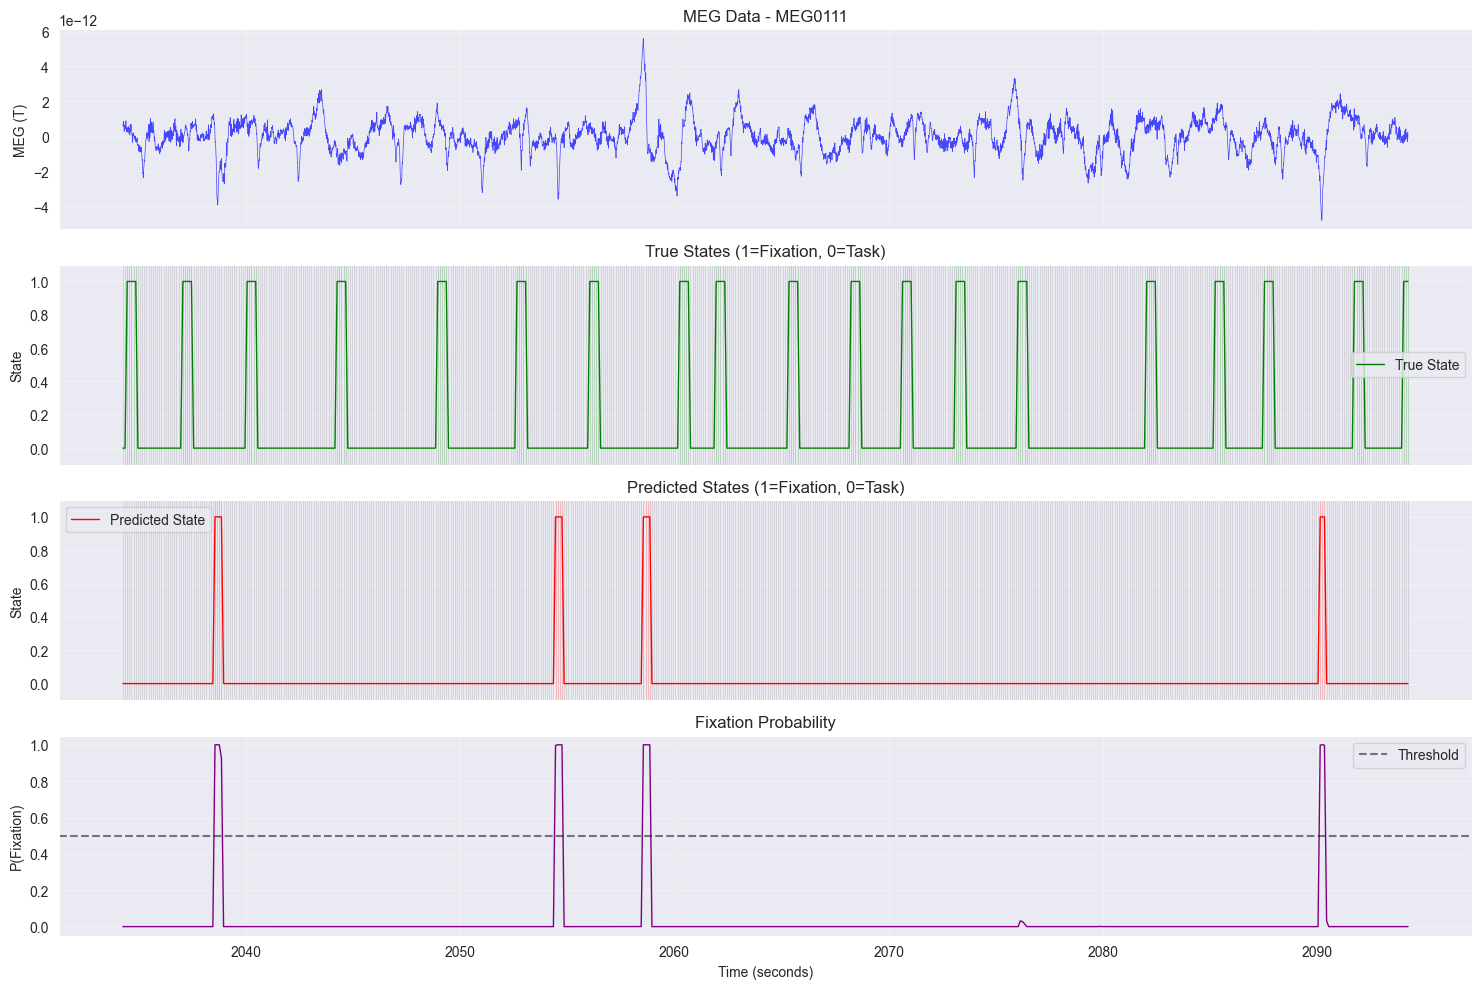

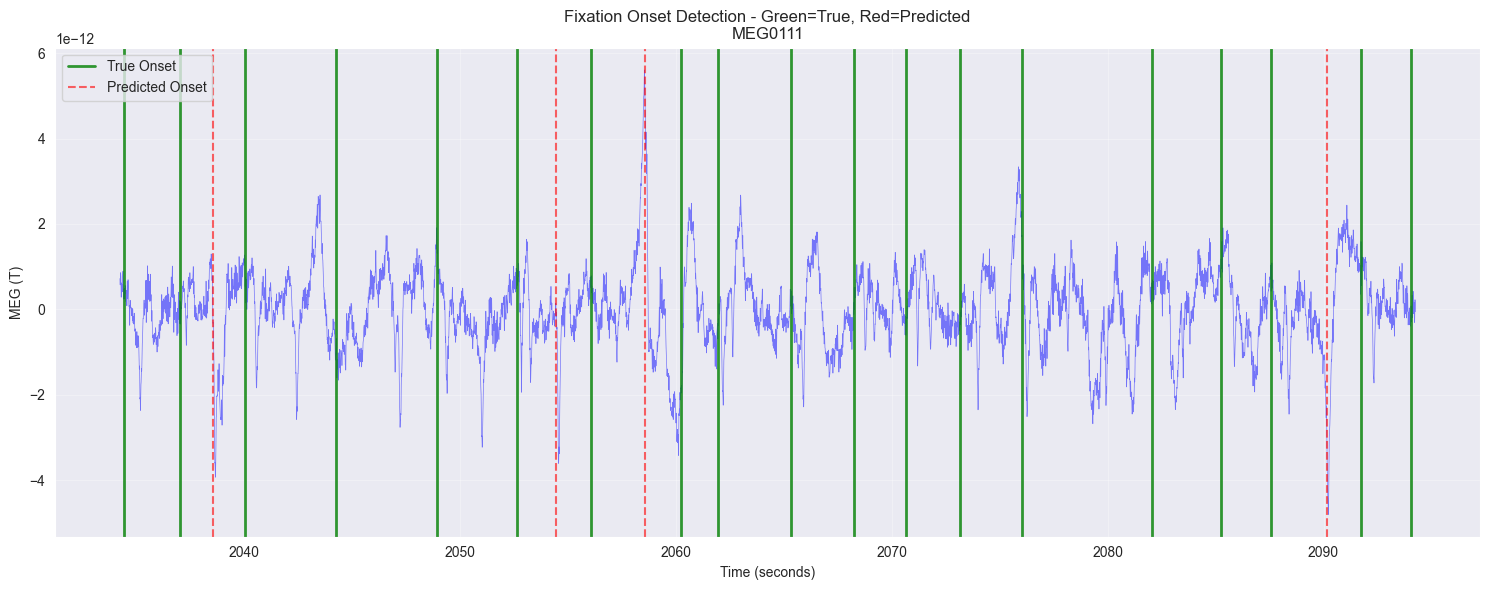


SUMMARY
Test duration: 508.4 seconds
True fixations: 159
Predicted fixations: 76
Timepoint accuracy: 0.8028

Onset detection (within 1 second tolerance):
  Precision: 0.5000
  Recall: 0.2390
  F1-score: 0.3234


In [102]:
plot_start = test_timestamps[0]
plot_end = min(test_timestamps[0] + 60, test_timestamps[-1])

# Get MEG data for the same period
meg_start_idx = int(plot_start * sfreq)
meg_end_idx = int(plot_end * sfreq)
meg_times = np.arange(meg_start_idx, meg_end_idx) / sfreq
meg_data = data[meg_start_idx:meg_end_idx]

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# Plot 1: Raw MEG data
axes[0].plot(meg_times, meg_data, 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('MEG (T)')
axes[0].set_title(f'MEG Data - {raw_mag.ch_names[0]}')
axes[0].grid(True, alpha=0.3)

# Plot 2: True states
for i, t in enumerate(test_timestamps):
    if plot_start <= t <= plot_end:
        color = 'green' if y_test[i] == 1 else 'gray'
        axes[1].axvline(x=t, color=color, linewidth=0.5, alpha=0.3)
axes[1].plot(test_timestamps[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            y_test[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            'g-', linewidth=1, label='True State')
axes[1].set_ylabel('State')
axes[1].set_title('True States (1=Fixation, 0=Task)')
axes[1].set_ylim([-0.1, 1.1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Predicted states
for i, t in enumerate(test_timestamps):
    if plot_start <= t <= plot_end:
        color = 'red' if predicted_states[i] == 1 else 'gray'
        axes[2].axvline(x=t, color=color, linewidth=0.5, alpha=0.3)
axes[2].plot(test_timestamps[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            predicted_states[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            'r-', linewidth=1, label='Predicted State')
axes[2].set_ylabel('State')
axes[2].set_title('Predicted States (1=Fixation, 0=Task)')
axes[2].set_ylim([-0.1, 1.1])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Fixation probability
axes[3].plot(test_timestamps[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            predicted_probs[(test_timestamps >= plot_start) & (test_timestamps <= plot_end)],
            'purple', linewidth=1)
axes[3].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[3].set_xlabel('Time (seconds)')
axes[3].set_ylabel('P(Fixation)')
axes[3].set_title('Fixation Probability')
axes[3].set_ylim([-0.05, 1.05])
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Step 7: Plot vertical lines for onsets
# ============================================================================
fig, ax = plt.subplots(figsize=(15, 6))

# Plot MEG data
ax.plot(meg_times, meg_data, 'b-', linewidth=0.5, alpha=0.5)

# Add true fixation onsets (green vertical lines)
for onset in true_onsets:
    if plot_start <= onset <= plot_end:
        ax.axvline(x=onset, color='green', linewidth=2, alpha=0.8, label='True Onset' if onset == true_onsets[0] else '')

# Add predicted fixation onsets (red vertical lines)
for onset in pred_onsets:
    if plot_start <= onset <= plot_end:
        ax.axvline(x=onset, color='red', linewidth=1.5, alpha=0.6, linestyle='--',
                  label='Predicted Onset' if onset == pred_onsets[0] else '')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('MEG (T)')
ax.set_title(f'Fixation Onset Detection - Green=True, Red=Predicted\n{raw_mag.ch_names[0]}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Test duration: {test_timestamps[-1] - test_timestamps[0]:.1f} seconds")
print(f"True fixations: {len(true_onsets)}")
print(f"Predicted fixations: {len(pred_onsets)}")
print(f"Timepoint accuracy: {accuracy:.4f}")

# Calculate onset detection metrics (simplified)
if len(true_onsets) > 0 and len(pred_onsets) > 0:
    # Count matches within 1 second
    matches = 0
    for true_onset in true_onsets:
        for pred_onset in pred_onsets:
            if abs(true_onset - pred_onset) < 1.0:
                matches += 1
                break

    precision = matches / len(pred_onsets) if len(pred_onsets) > 0 else 0
    recall = matches / len(true_onsets) if len(true_onsets) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nOnset detection (within 1 second tolerance):")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")

## pics